In [55]:
# !pip install pyreadr
# !pip install matplotlib
# !pip install seaborn
# !pip install scipy
# !pip install scikit-learn
# !pip install adjustText

In [56]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## Setup - Common Definitions
Run this cell once after loading the data.

In [57]:
# ============================================================================
# SETUP CELL - Common Definitions for All Plots
# Run this cell once after loading the data
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Continent Mapping

# Continent Colors

# Subjects
SUBJECTS = ['MATH', 'READ', 'SCIE', 'GLCM']
SUBJECT_NAMES = ['Mathematics', 'Reading', 'Science', 'Global Competence']
CONTINENTS = ['Europe', 'Asia', 'Americas', 'Oceania', 'Africa']

# Add continent column to dataframe

print("✓ Setup complete! Continent mapping applied to df.")


✓ Setup complete! Continent mapping applied to df.


In [58]:
result = pyreadr.read_r('./pisa2018.Rdata') # also works for Rds
print(result.keys()) # let's check what objects we got

odict_keys(['newdata'])


In [59]:
df = result["newdata"] # extract the pandas data frame for object df1
df

,CNTRYID,CNT,CNTSCHID,CNTSTUID,ST001D01T,ST003D02T,ST003D03T,ST004D01T,ST005Q01TA,ST007Q01TA,MATH,READ,SCIE,GLCM
0,Albania,Albania,800002.0,800251.0,Grade 10,February,2002,Male,ISCED level 3A,ISCED level 3A,446.8485,374.4487,419.5857,396.2413
1,Albania,Albania,800002.0,800402.0,Grade 10,July,2002,Male,ISCED level 2,ISCED level 2,479.5390,439.1777,421.4702,456.6411
2,Albania,Albania,800002.0,801902.0,Grade 10,April,2002,Female,ISCED level 2,ISCED level 2,442.7338,335.0039,412.9560,354.2925
3,Albania,Albania,800002.0,803546.0,Grade 10,April,2002,Male,ISCED level 2,ISCED level 2,444.5389,409.7485,465.6998,357.8089
4,Albania,Albania,800002.0,804776.0,Grade 10,March,2002,Male,ISCED level 2,ISCED level 3A,473.8211,345.2832,395.1858,368.0848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611999,Vietnam,Vietnam,70400152.0,70405094.0,Ungraded,February,2002,Male,ISCED level 1,He did not complete ISCED level 1,NaN,NaN,NaN,NaN
612000,Vietnam,Vietnam,70400152.0,70405205.0,Ungraded,February,2002,Female,ISCED level 3A,NaN,NaN,NaN,NaN,NaN
612001,Vietnam,Vietnam,70400152.0,70405219.0,Ungraded,February,2002,Female,She did not complete ISCED level 1,ISCED level 1,NaN,NaN,NaN,NaN
612002,Vietnam,Vietnam,70400152.0,70405253.0,Ungraded,October,2002,Male,ISCED level 3A,He did not complete ISCED level 1,NaN,NaN,NaN,NaN


In [60]:
print(f"Dataset shape: {df.shape}")
print(f"Total students: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
df.dtypes

Dataset shape: (612004, 14)
Total students: 612,004

Columns: ['CNTRYID', 'CNT', 'CNTSCHID', 'CNTSTUID', 'ST001D01T', 'ST003D02T', 'ST003D03T', 'ST004D01T', 'ST005Q01TA', 'ST007Q01TA', 'MATH', 'READ', 'SCIE', 'GLCM']


CNTRYID       category
CNT           category
CNTSCHID       float64
CNTSTUID       float64
ST001D01T     category
ST003D02T     category
ST003D03T     category
ST004D01T     category
ST005Q01TA    category
ST007Q01TA    category
MATH           float64
READ           float64
SCIE           float64
GLCM           float64
dtype: object

In [61]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
missing_data

score_cols = ['MATH', 'READ', 'SCIE', 'GLCM']
print(f"Students with complete scores: {df[score_cols].notna().all(axis=1).sum():,}")
print(f"Students with missing scores: {df[score_cols].isna().any(axis=1).sum():,}")

Students with complete scores: 246,750
Students with missing scores: 365,254


In [62]:
country_stats = df.groupby('CNT').agg({
    'CNTSTUID': 'count',
    'MATH': 'count',
    'READ': 'count',
    'SCIE': 'count',
    'GLCM': 'count'
}).rename(columns={'CNTSTUID': 'Total_Students'})

country_stats.columns = ['Total_Students', 'MATH_Valid', 'READ_Valid', 'SCIE_Valid', 'GLCM_Valid']
country_stats = country_stats.sort_values('Total_Students', ascending=False)

print(f"Total countries: {df['CNT'].nunique()}")
country_stats

Total countries: 80


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/2880853942.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_stats = df.groupby('CNT').agg({


,Total_Students,MATH_Valid,READ_Valid,SCIE_Valid,GLCM_Valid
CNT,,,,,
Spain,35943,35943,35943,35943,35943
Canada,22653,22653,22653,22653,22653
Kazakhstan,19507,19507,19507,19507,19507
United Arab Emirates,19277,19277,19277,19277,0
Australia,14273,14273,14273,14273,0
Qatar,13828,13828,13828,13828,0
United Kingdom,13818,13818,13818,13818,2998
Indonesia,12098,12098,12098,12098,12098
B-S-J-Z (China),12058,12058,12058,12058,0


In [63]:
greece_data = df[df['CNT'] == 'Greece'].copy()

print(f"Greece sample size: {len(greece_data):,}")
print(f"\nGrade distribution:")
print(greece_data['ST001D01T'].value_counts())
print(f"\nGender distribution:")
print(greece_data['ST004D01T'].value_counts())

greece_data[score_cols].describe().round(1)

Greece sample size: 6,403

Grade distribution:
ST001D01T
Grade 10    6252
Grade 9      124
Grade 8       24
Grade 7        3
Grade 11       0
Grade 12       0
Grade 13       0
Invalid        0
Ungraded       0
Name: count, dtype: int64

Gender distribution:
ST004D01T
Male      3225
Female    3178
Name: count, dtype: int64


,MATH,READ,SCIE,GLCM
count,6403.0,6403.0,6403.0,6403.0
mean,454.2,460.6,454.3,491.1
std,80.4,93.3,79.2,89.3
min,151.0,190.1,145.6,162.5
25%,398.8,396.5,397.3,428.1
50%,455.9,463.9,456.7,493.0
75%,510.2,527.4,511.5,556.3
max,706.9,742.4,712.6,750.0


In [64]:
df[score_cols].describe().round(1)


,MATH,READ,SCIE,GLCM
count,606627.0,606627.0,606627.0,246750.0
mean,461.1,456.1,460.7,480.3
std,98.4,105.1,97.9,98.4
min,85.8,70.3,105.1,140.4
25%,389.1,379.5,387.2,405.9
50%,460.0,456.1,458.0,476.5
75%,532.3,532.7,531.4,551.6
max,825.2,823.4,843.2,862.1


In [65]:
country_means = df.groupby('CNT')[score_cols].mean().round(2)
country_means['Average_Score'] = country_means[['MATH', 'READ', 'SCIE']].mean(axis=1).round(2)

for col in ['MATH', 'READ', 'SCIE', 'GLCM', 'Average_Score']:
    country_means[f'{col}_Rank'] = country_means[col].rank(ascending=False, method='min')

country_means_sorted = country_means.sort_values('Average_Score', ascending=False)

display_cols = ['MATH', 'READ', 'SCIE', 'Average_Score', 'Average_Score_Rank']
print("Top 10 countries:")
print(country_means_sorted[display_cols].head(10))

print("\nGreece position:")
country_means.loc['Greece']

Top 10 countries:
                   MATH    READ    SCIE  Average_Score  Average_Score_Rank
CNT                                                                       
B-S-J-Z (China)  593.07  560.52  593.58         582.39                 1.0
Singapore        568.29  548.46  549.97         555.57                 2.0
Macao            557.66  525.07  543.54         542.09                 3.0
Hong Kong        553.92  527.16  518.51         533.20                 4.0
Estonia          523.48  523.27  530.11         525.62                 5.0
Korea            527.55  515.75  520.33         521.21                 6.0
Japan            526.59  503.48  529.01         519.69                 7.0
Finland          507.51  520.33  522.05         516.63                 8.0
Poland           516.42  512.63  511.78         513.61                 9.0
Chinese Taipei   526.85  498.00  510.76         511.87                10.0

Greece position:


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/3466261655.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_means = df.groupby('CNT')[score_cols].mean().round(2)


MATH                  454.22
READ                  460.62
SCIE                  454.33
GLCM                  491.14
Average_Score         456.39
MATH_Rank              45.00
READ_Rank              45.00
SCIE_Rank              47.00
GLCM_Rank              11.00
Average_Score_Rank     46.00
Name: Greece, dtype: float64

In [66]:
gender_pivot = {}
for subject in score_cols:
    pivot = df.pivot_table(values=subject, index='CNT', columns='ST004D01T', aggfunc='mean')
    if 'Male' in pivot.columns and 'Female' in pivot.columns:
        gender_pivot[subject] = pivot[['Male', 'Female']].copy()
        gender_pivot[subject][f'{subject}_Gap'] = (pivot['Male'] - pivot['Female']).round(2)

gender_gaps = pd.DataFrame()
for subject in score_cols:
    if subject in gender_pivot:
        gender_gaps[f'{subject}_Male'] = gender_pivot[subject]['Male']
        gender_gaps[f'{subject}_Female'] = gender_pivot[subject]['Female']
        gender_gaps[f'{subject}_Gap'] = gender_pivot[subject][f'{subject}_Gap']

gap_cols = [col for col in gender_gaps.columns if col.endswith('_Gap') and not col.startswith('GLCM')]
gender_gaps['Avg_Gap'] = gender_gaps[gap_cols].mean(axis=1).round(2)
gender_gaps_sorted = gender_gaps.sort_values('Avg_Gap', ascending=False)

print("Countries with largest gender gaps (Male - Female):")
print(gender_gaps_sorted[['MATH_Gap', 'READ_Gap', 'SCIE_Gap', 'Avg_Gap']].head(10))

print("\nGreece gender gaps:")
gender_gaps.loc['Greece'][['MATH_Gap', 'READ_Gap', 'SCIE_Gap', 'Avg_Gap']]

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/3411195025.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values=subject, index='CNT', columns='ST004D01T', aggfunc='mean')
/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/3411195025.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values=subject, index='CNT', columns='ST004D01T', aggfunc='mean')
/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/3411195025.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to s

Countries with largest gender gaps (Male - Female):
                 MATH_Gap  READ_Gap  SCIE_Gap  Avg_Gap
CNT                                                   
Colombia            20.84     -8.90     14.11     8.68
Peru                16.51    -10.67     13.19     6.34
Argentina           18.73    -12.71     12.66     6.23
Costa Rica          19.39    -12.91     11.14     5.87
Mexico              14.35    -10.17      9.90     4.69
B-S-J-Z (China)      7.46    -15.80      8.12    -0.07
Panama               9.43    -12.35      1.64    -0.43
Chile                9.70    -16.64      5.50    -0.48
Belgium             12.33    -21.44      4.99    -1.37
Korea                7.11    -20.72      6.58    -2.34

Greece gender gaps:


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/3411195025.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values=subject, index='CNT', columns='ST004D01T', aggfunc='mean')


MATH_Gap     1.49
READ_Gap   -40.67
SCIE_Gap   -10.45
Avg_Gap    -16.54
Name: Greece, dtype: float64

In [67]:
print("Mother's education:")
print(df['ST005Q01TA'].value_counts())

df.groupby('ST005Q01TA')[score_cols].mean().round(1)

Mother's education:
ST005Q01TA
ISCED level 3A                         319865
ISCED level 3B, 3C                     113304
ISCED level 2                          100956
ISCED level 1                           34557
She did not complete  ISCED level 1     18055
Name: count, dtype: int64


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/322134205.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ST005Q01TA')[score_cols].mean().round(1)


,MATH,READ,SCIE,GLCM
ST005Q01TA,,,,
ISCED level 1,407.1,404.8,413.7,434.0
ISCED level 2,427.4,421.4,428.4,439.5
ISCED level 3A,483.9,479.6,482.8,503.8
"ISCED level 3B, 3C",460.3,454.2,457.9,476.6
She did not complete ISCED level 1,385.5,383.2,391.5,409.6


### Plot Number 1

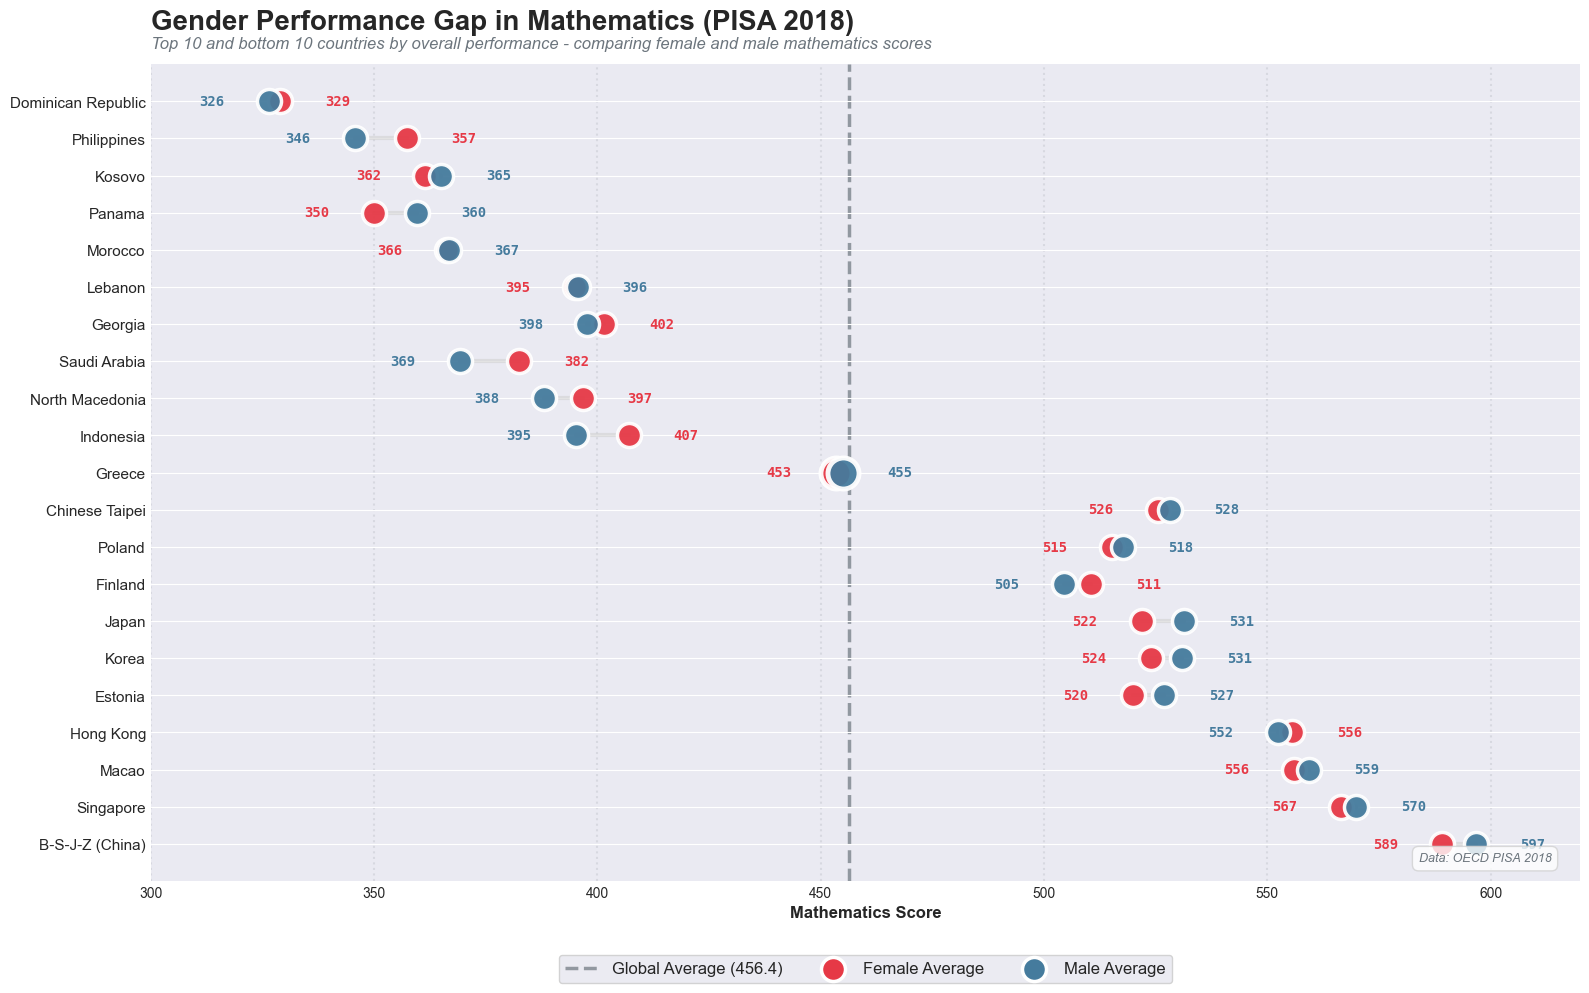

In [68]:
fig, ax = plt.subplots(figsize=(16, 10))

plot_data = gender_gaps[['MATH_Male', 'MATH_Female', 'MATH_Gap']].join(country_means[['Average_Score']])
plot_data = plot_data.dropna()
plot_data_sorted = plot_data.sort_values('Average_Score', ascending=False)

top_10 = plot_data_sorted.head(10)
bottom_10 = plot_data_sorted.tail(10)

if 'Greece' in plot_data_sorted.index:
    greece_row = plot_data_sorted.loc[['Greece']]
    selected_countries = pd.concat([top_10, greece_row, bottom_10])
else:
    selected_countries = pd.concat([top_10, bottom_10])

selected_countries = selected_countries[~selected_countries.index.duplicated(keep='first')]

global_avg = selected_countries[['MATH_Male', 'MATH_Female']].mean().mean()

for i, (country, row) in enumerate(selected_countries.iterrows()):
    is_greece = (country == 'Greece')
    
    line_color = '#1A535C' if is_greece else '#D1D1D1'
    line_width = 7 if is_greece else 3
    line_alpha = 1.0 if is_greece else 0.6
    
    ax.plot([row['MATH_Female'], row['MATH_Male']], [i, i], 
           color=line_color, linewidth=line_width, alpha=line_alpha,
           solid_capstyle='round', zorder=1)
    
    dot_size = 500 if is_greece else 300
    edge_width = 3.5 if is_greece else 2.5
    
    ax.scatter(row['MATH_Female'], i, s=dot_size, 
              color='#E63946', edgecolors='white', linewidths=edge_width, 
              zorder=3, alpha=0.95)
    ax.scatter(row['MATH_Male'], i, s=dot_size, 
              color='#457B9D', edgecolors='white', linewidths=edge_width, 
              zorder=3, alpha=0.95)
    
    female_label = f"{row['MATH_Female']:.0f}"
    male_label = f"{row['MATH_Male']:.0f}"
    
    if row['MATH_Female'] < row['MATH_Male']:
        ax.text(row['MATH_Female'] - 10, i, female_label, 
               va='center', ha='right', fontsize=10, fontweight='bold', 
               color='#E63946', family='monospace')
        ax.text(row['MATH_Male'] + 10, i, male_label, 
               va='center', ha='left', fontsize=10, fontweight='bold', 
               color='#457B9D', family='monospace')
    else:
        ax.text(row['MATH_Male'] - 10, i, male_label, 
               va='center', ha='right', fontsize=10, fontweight='bold', 
               color='#457B9D', family='monospace')
        ax.text(row['MATH_Female'] + 10, i, female_label, 
               va='center', ha='left', fontsize=10, fontweight='bold', 
               color='#E63946', family='monospace')

ax.axvline(x=global_avg, color='#6C757D', linestyle='--', 
          linewidth=2.5, alpha=0.7, zorder=0, label=f'Global Average ({global_avg:.1f})')

ax.set_yticks(range(len(selected_countries)))
ax.set_yticklabels(selected_countries.index, fontsize=11, fontfamily='sans-serif')

ax.set_xlabel('Mathematics Score', fontsize=12, fontweight='bold')
ax.set_title('Gender Performance Gap in Mathematics (PISA 2018)', 
            fontsize=20, fontweight='bold', pad=25, loc='left', family='sans-serif')
ax.text(0, 1.02, 'Top 10 and bottom 10 countries by overall performance - comparing female and male mathematics scores', 
       transform=ax.transAxes, fontsize=12, style='italic', color='#6C757D')

legend_y = -0.08
ax.scatter([], [], s=300, color='#E63946', edgecolors='white', linewidths=2.5, label='Female Average')
ax.scatter([], [], s=300, color='#457B9D', edgecolors='white', linewidths=2.5, label='Male Average')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, legend_y), 
         ncol=3, frameon=True, framealpha=0.95, 
         fontsize=12, edgecolor='#D1D1D1', fancybox=True)

ax.text(0.98, 0.02, 'Data: OECD PISA 2018', 
       transform=ax.transAxes, fontsize=9, va='bottom', ha='right',
       color='#6C757D', style='italic',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                edgecolor='#D1D1D1', alpha=0.8))

ax.set_xlim(300, 620)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=True)
ax.set_xticks(range(300, 621, 50))
ax.tick_params(axis='x', labelsize=10, color='#6C757D')

ax.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1.5, color='#6C757D')

plt.tight_layout()
plt.show()

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/1684028255.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


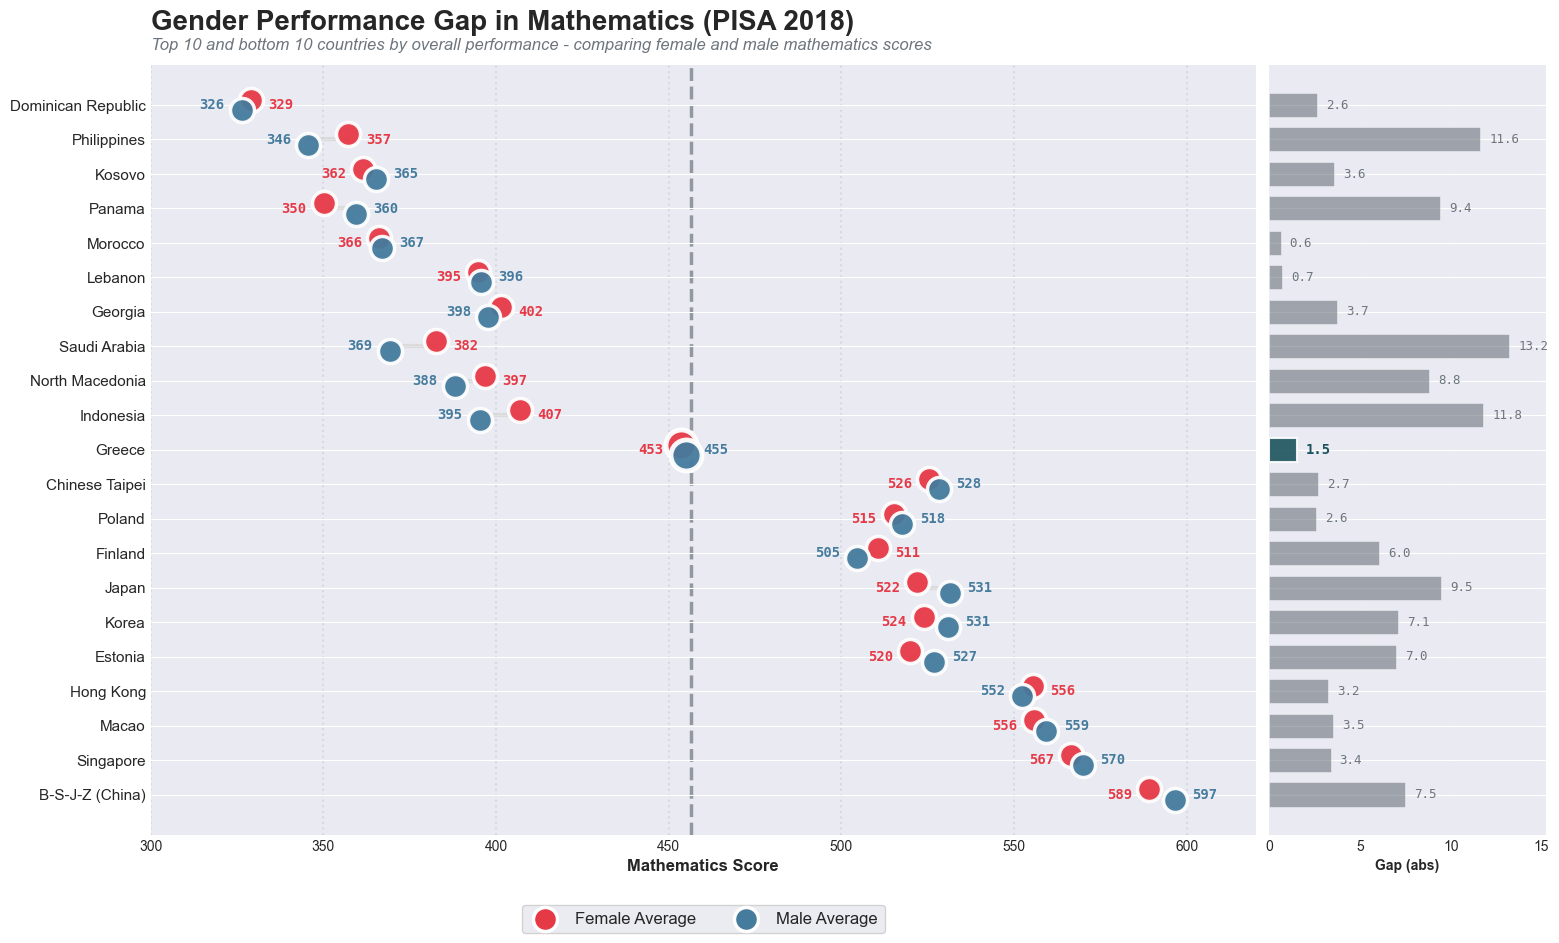

In [69]:
fig, (ax_main, ax_gap) = plt.subplots(1, 2, figsize=(18, 10), 
                                       gridspec_kw={'width_ratios': [4, 1], 'wspace': 0.02})

plot_data = gender_gaps[['MATH_Male', 'MATH_Female', 'MATH_Gap']].join(country_means[['Average_Score']])
plot_data = plot_data.dropna()
plot_data_sorted = plot_data.sort_values('Average_Score', ascending=False)

top_10 = plot_data_sorted.head(10)
bottom_10 = plot_data_sorted.tail(10)

if 'Greece' in plot_data_sorted.index:
    greece_row = plot_data_sorted.loc[['Greece']]
    selected_countries = pd.concat([top_10, greece_row, bottom_10])
else:
    selected_countries = pd.concat([top_10, bottom_10])

selected_countries = selected_countries[~selected_countries.index.duplicated(keep='first')]

global_avg = selected_countries[['MATH_Male', 'MATH_Female']].mean().mean()

offset = 0.15

# Main plot
for i, (country, row) in enumerate(selected_countries.iterrows()):
    is_greece = (country == 'Greece')
    
    line_color = '#1A535C' if is_greece else '#D1D1D1'
    line_width = 7 if is_greece else 3
    line_alpha = 1.0 if is_greece else 0.6
    
    ax_main.plot([row['MATH_Female'], row['MATH_Male']], [i, i], 
           color=line_color, linewidth=line_width, alpha=line_alpha,
           solid_capstyle='round', zorder=1)
    
    dot_size = 500 if is_greece else 300
    edge_width = 3.5 if is_greece else 2.5
    
    ax_main.scatter(row['MATH_Female'], i + offset, s=dot_size, 
              color='#E63946', edgecolors='white', linewidths=edge_width, 
              zorder=3, alpha=0.95)
    ax_main.scatter(row['MATH_Male'], i - offset, s=dot_size, 
              color='#457B9D', edgecolors='white', linewidths=edge_width, 
              zorder=3, alpha=0.95)
    
    female_label = f"{row['MATH_Female']:.0f}"
    male_label = f"{row['MATH_Male']:.0f}"
    
    if row['MATH_Female'] < row['MATH_Male']:
        ax_main.text(row['MATH_Female'] - 5, i, female_label, 
               va='center', ha='right', fontsize=10, fontweight='bold', 
               color='#E63946', family='monospace')
        ax_main.text(row['MATH_Male'] + 5, i, male_label, 
               va='center', ha='left', fontsize=10, fontweight='bold', 
               color='#457B9D', family='monospace')
    else:
        ax_main.text(row['MATH_Male'] - 5, i, male_label, 
               va='center', ha='right', fontsize=10, fontweight='bold', 
               color='#457B9D', family='monospace')
        ax_main.text(row['MATH_Female'] + 5, i, female_label, 
               va='center', ha='left', fontsize=10, fontweight='bold', 
               color='#E63946', family='monospace')

# Gap panel
for i, (country, row) in enumerate(selected_countries.iterrows()):
    is_greece = (country == 'Greece')
    gap = abs(row['MATH_Gap'])
    
    bar_color = '#1A535C' if is_greece else '#6C757D'
    bar_alpha = 0.9 if is_greece else 0.6
    
    ax_gap.barh(i, gap, height=0.7, color=bar_color, alpha=bar_alpha, 
                edgecolor='white', linewidth=1.5 if is_greece else 0.5)
    
    ax_gap.text(gap + 0.5, i, f"{gap:.1f}", va='center', ha='left',
                fontsize=10 if is_greece else 9, fontweight='bold' if is_greece else 'normal',
                color=bar_color, family='monospace')

ax_main.axvline(x=global_avg, color='#6C757D', linestyle='--', 
          linewidth=2.5, alpha=0.7, zorder=0)

ax_main.set_yticks(range(len(selected_countries)))
ax_main.set_yticklabels(selected_countries.index, fontsize=11, fontfamily='sans-serif')

ax_main.set_xlabel('Mathematics Score', fontsize=12, fontweight='bold')
ax_main.set_title('Gender Performance Gap in Mathematics (PISA 2018)', 
            fontsize=20, fontweight='bold', pad=25, loc='left', family='sans-serif')
ax_main.text(0, 1.02, 'Top 10 and bottom 10 countries by overall performance - comparing female and male mathematics scores', 
       transform=ax_main.transAxes, fontsize=12, style='italic', color='#6C757D')

legend_y = -0.08
ax_main.scatter([], [], s=300, color='#E63946', edgecolors='white', linewidths=2.5, label='Female Average')
ax_main.scatter([], [], s=300, color='#457B9D', edgecolors='white', linewidths=2.5, label='Male Average')
ax_main.legend(loc='upper center', bbox_to_anchor=(0.5, legend_y), 
         ncol=3, frameon=True, framealpha=0.95, 
         fontsize=12, edgecolor='#D1D1D1', fancybox=True)

ax_main.set_xlim(300, 620)

for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.tick_params(left=False, bottom=True)
ax_main.set_xticks(range(300, 621, 50))
ax_main.tick_params(axis='x', labelsize=10, color='#6C757D')
ax_main.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1.5, color='#6C757D')

# Gap panel styling
ax_gap.set_yticks(range(len(selected_countries)))
ax_gap.set_yticklabels([])
ax_gap.set_ylim(ax_main.get_ylim())
ax_gap.set_xlabel('Gap (abs)', fontsize=10, fontweight='bold')
ax_gap.set_xlim(0, max(abs(selected_countries['MATH_Gap'])) + 2)
ax_gap.tick_params(left=False, bottom=True)
ax_gap.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1)

for spine in ax_gap.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### Plot Number 2

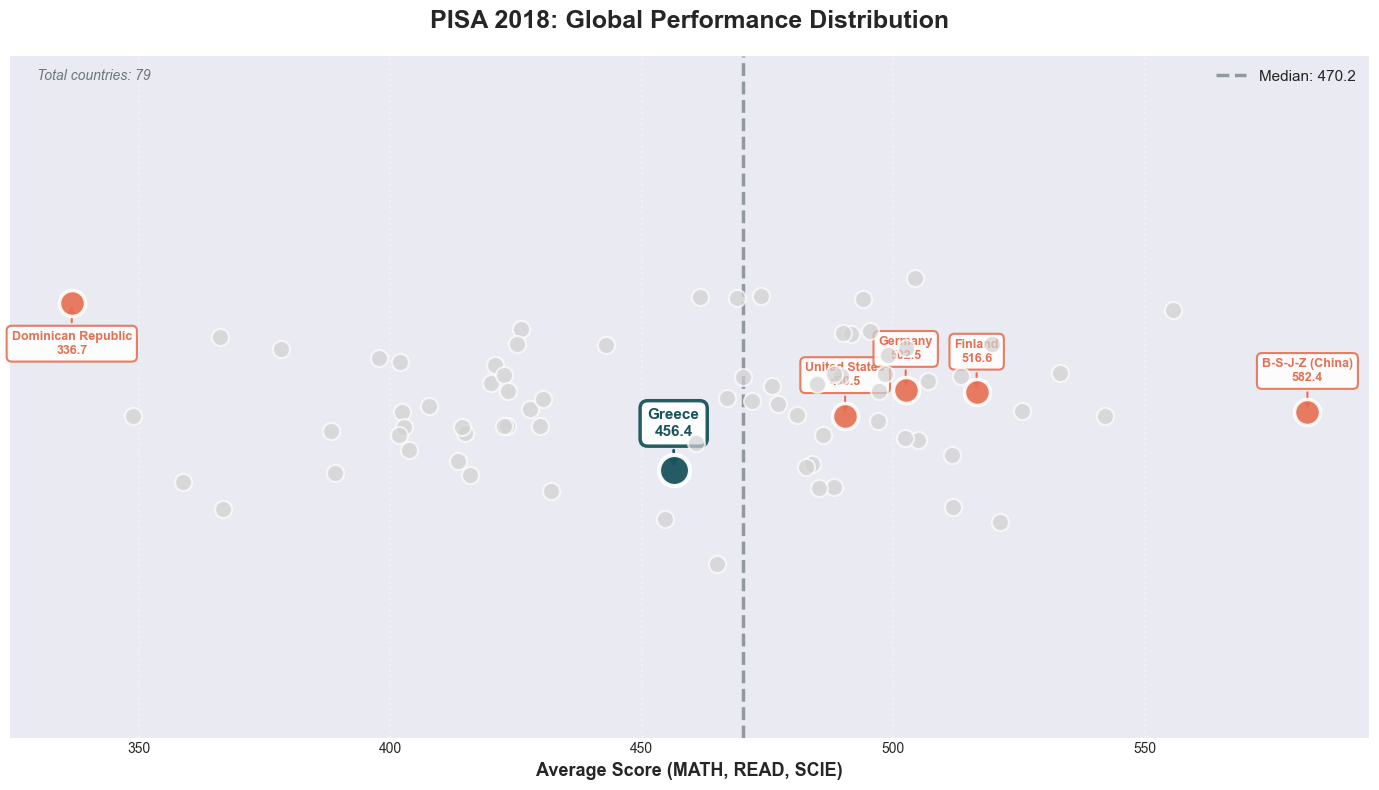

In [70]:
fig, ax = plt.subplots(figsize=(14, 8))

all_scores = country_means['Average_Score'].dropna()

np.random.seed(42)
y_positions = np.random.normal(0, 0.15, size=len(all_scores))

notable_countries = []
notable_countries.append(all_scores.idxmax())
notable_countries.append(all_scores.idxmin())

if 'Greece' in all_scores.index:
    notable_countries.append('Greece')
if 'United States' in all_scores.index:
    notable_countries.append('United States')
if 'India' in all_scores.index:
    notable_countries.append('India')
if 'Germany' in all_scores.index:
    notable_countries.append('Germany')
if 'Finland' in all_scores.index:
    notable_countries.append('Finland')

for i, (country, score) in enumerate(all_scores.items()):
    if country == 'Greece':
        ax.scatter(score, y_positions[i], s=500, color='#1A535C', 
                  edgecolors='white', linewidths=3, zorder=10, alpha=0.95)
    elif country in notable_countries:
        ax.scatter(score, y_positions[i], s=350, color='#E76F51', 
                  edgecolors='white', linewidths=2.5, zorder=8, alpha=0.9)
    else:
        ax.scatter(score, y_positions[i], s=150, color='#D1D1D1', 
                  edgecolors='white', linewidths=1.5, zorder=5, alpha=0.7)

for country in notable_countries:
    if country in all_scores.index:
        score = all_scores[country]
        country_idx = list(all_scores.index).index(country)
        
        if country == 'Greece':
            ax.annotate(f'{country}\n{score:.1f}', 
                       xy=(score, y_positions[country_idx]),
                       xytext=(0, 25), textcoords='offset points',
                       ha='center', fontsize=11, fontweight='bold',
                       color='#1A535C',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                                edgecolor='#1A535C', linewidth=2.5, alpha=0.95),
                       arrowprops=dict(arrowstyle='->', lw=2, color='#1A535C'))
        else:
            offset_y = 20 if score > all_scores.median() else -20
            va = 'bottom' if score > all_scores.median() else 'top'
            ax.annotate(f'{country}\n{score:.1f}', 
                       xy=(score, y_positions[country_idx]),
                       xytext=(0, offset_y), textcoords='offset points',
                       ha='center', fontsize=9, fontweight='bold',
                       color='#E76F51', va=va,
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                                edgecolor='#E76F51', linewidth=1.5, alpha=0.9),
                       arrowprops=dict(arrowstyle='->', lw=1.5, color='#E76F51'))

oecd_avg = all_scores.median()
ax.axvline(x=oecd_avg, color='#6C757D', linestyle='--', linewidth=2.5, alpha=0.7,
          label=f'Median: {oecd_avg:.1f}', zorder=3)

ax.set_xlabel('Average Score (MATH, READ, SCIE)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_title('PISA 2018: Global Performance Distribution', 
            fontsize=18, fontweight='bold', pad=20)

ax.text(0.02, 0.98, f'Total countries: {len(all_scores)}', 
       transform=ax.transAxes, fontsize=10, va='top', style='italic', color='#6C757D')

ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(-0.8, 0.8)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3, linestyle=':', linewidth=1.5)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

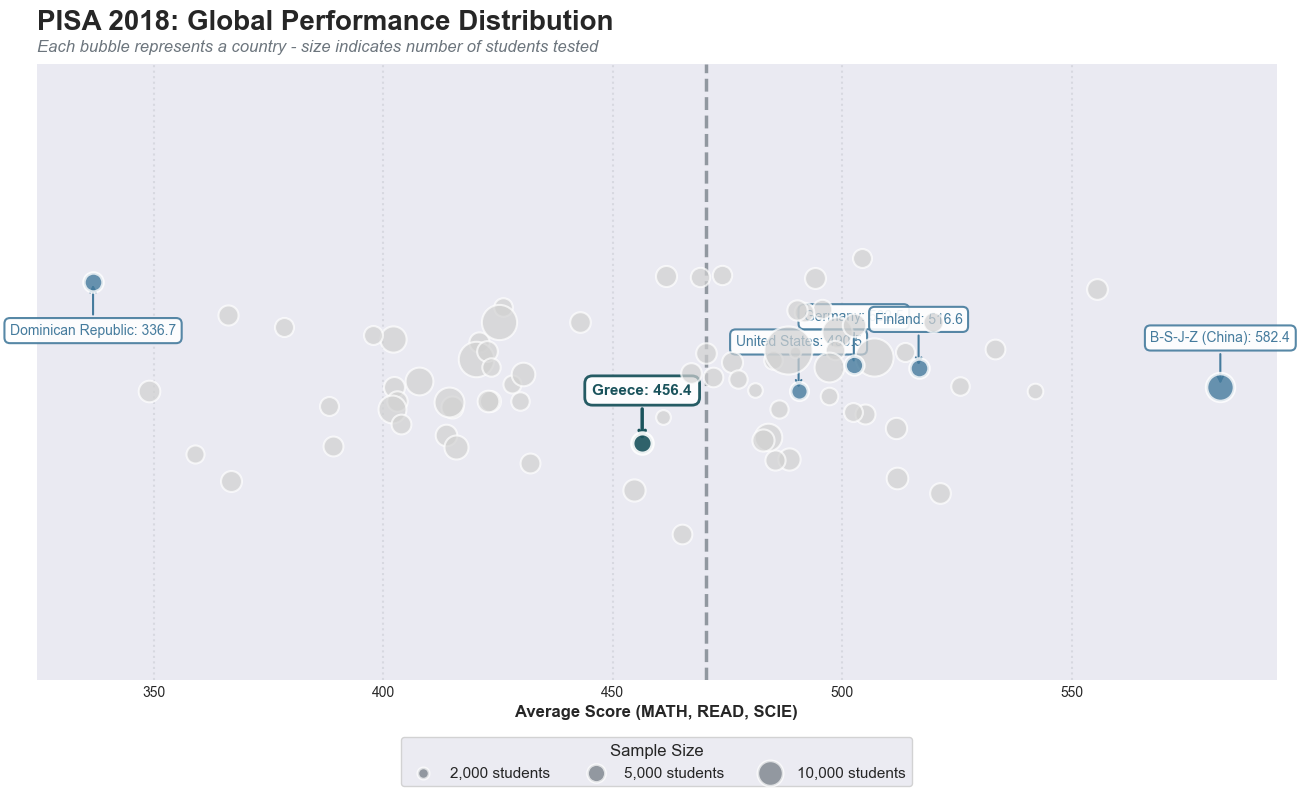

In [71]:
fig, ax = plt.subplots(figsize=(16, 8))

all_scores = country_means['Average_Score'].dropna()
sample_sizes = country_stats.loc[all_scores.index, 'Total_Students']

np.random.seed(42)
y_positions = np.random.normal(0, 0.12, size=len(all_scores))

notable_countries = []
notable_countries.append(all_scores.idxmax())
notable_countries.append(all_scores.idxmin())

if 'Greece' in all_scores.index:
    notable_countries.append('Greece')
if 'United States' in all_scores.index:
    notable_countries.append('United States')
if 'Germany' in all_scores.index:
    notable_countries.append('Germany')
if 'Finland' in all_scores.index:
    notable_countries.append('Finland')

bubble_scale = 30

for i, (country, score) in enumerate(all_scores.items()):
    size = sample_sizes[country] / bubble_scale
    
    if country == 'Greece':
        ax.scatter(score, y_positions[i], s=size, color='#1A535C', 
                  edgecolors='white', linewidths=3, zorder=10, alpha=0.9)
    elif country in notable_countries:
        ax.scatter(score, y_positions[i], s=size, color='#457B9D', 
                  edgecolors='white', linewidths=2.5, zorder=8, alpha=0.8)
    else:
        ax.scatter(score, y_positions[i], s=size, color='#D1D1D1', 
                  edgecolors='white', linewidths=1.5, zorder=5, alpha=0.7)

for country in notable_countries:
    if country in all_scores.index:
        score = all_scores[country]
        country_idx = list(all_scores.index).index(country)
        sample = sample_sizes[country]
        
        if country == 'Greece':
            ax.annotate(f'{country}: {score:.1f}', 
                       xy=(score, y_positions[country_idx]),
                       xytext=(0, 35), textcoords='offset points',
                       ha='center', fontsize=11, fontweight='bold',
                       color='#1A535C', family='sans-serif',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                                edgecolor='#1A535C', linewidth=2, alpha=0.95),
                       arrowprops=dict(arrowstyle='->', lw=2.5, color='#1A535C'))
        else:
            offset_y = 30 if score > all_scores.median() else -30
            va = 'bottom' if score > all_scores.median() else 'top'
            ax.annotate(f'{country}: {score:.1f}', 
                       xy=(score, y_positions[country_idx]),
                       xytext=(0, offset_y), textcoords='offset points',
                       ha='center', fontsize=10, fontweight='normal',
                       color='#457B9D', va=va, family='sans-serif',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                                edgecolor='#457B9D', linewidth=1.5, alpha=0.9),
                       arrowprops=dict(arrowstyle='->', lw=1.5, color='#457B9D'))

oecd_avg = all_scores.median()
ax.axvline(x=oecd_avg, color='#6C757D', linestyle='--', linewidth=2.5, alpha=0.7, zorder=3)

ax.set_xlabel('Average Score (MATH, READ, SCIE)', fontsize=12, fontweight='bold', family='sans-serif')
ax.set_ylabel('')
ax.set_title('PISA 2018: Global Performance Distribution', 
            fontsize=20, fontweight='bold', pad=25, loc='left', family='sans-serif')
ax.text(0, 1.02, 'Each bubble represents a country - size indicates number of students tested', 
       transform=ax.transAxes, fontsize=12, style='italic', color='#6C757D')

legend_sizes = [2000, 5000, 10000]
for sz in legend_sizes:
    ax.scatter([], [], s=sz/bubble_scale, color='#6C757D', 
              edgecolors='white', linewidths=2, alpha=0.7,
              label=f'{sz:,} students')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), 
         ncol=4, frameon=True, framealpha=0.95, 
         fontsize=11, edgecolor='#D1D1D1', fancybox=True,
         title='Sample Size', title_fontsize=12)

ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1.5, color='#6C757D')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=True)
ax.tick_params(axis='x', labelsize=10, color='#6C757D')

# plt.tight_layout()
plt.show()

### Plot Number 3

/opt/homebrew/Caskroom/miniconda/base/envs/data_visualisation/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


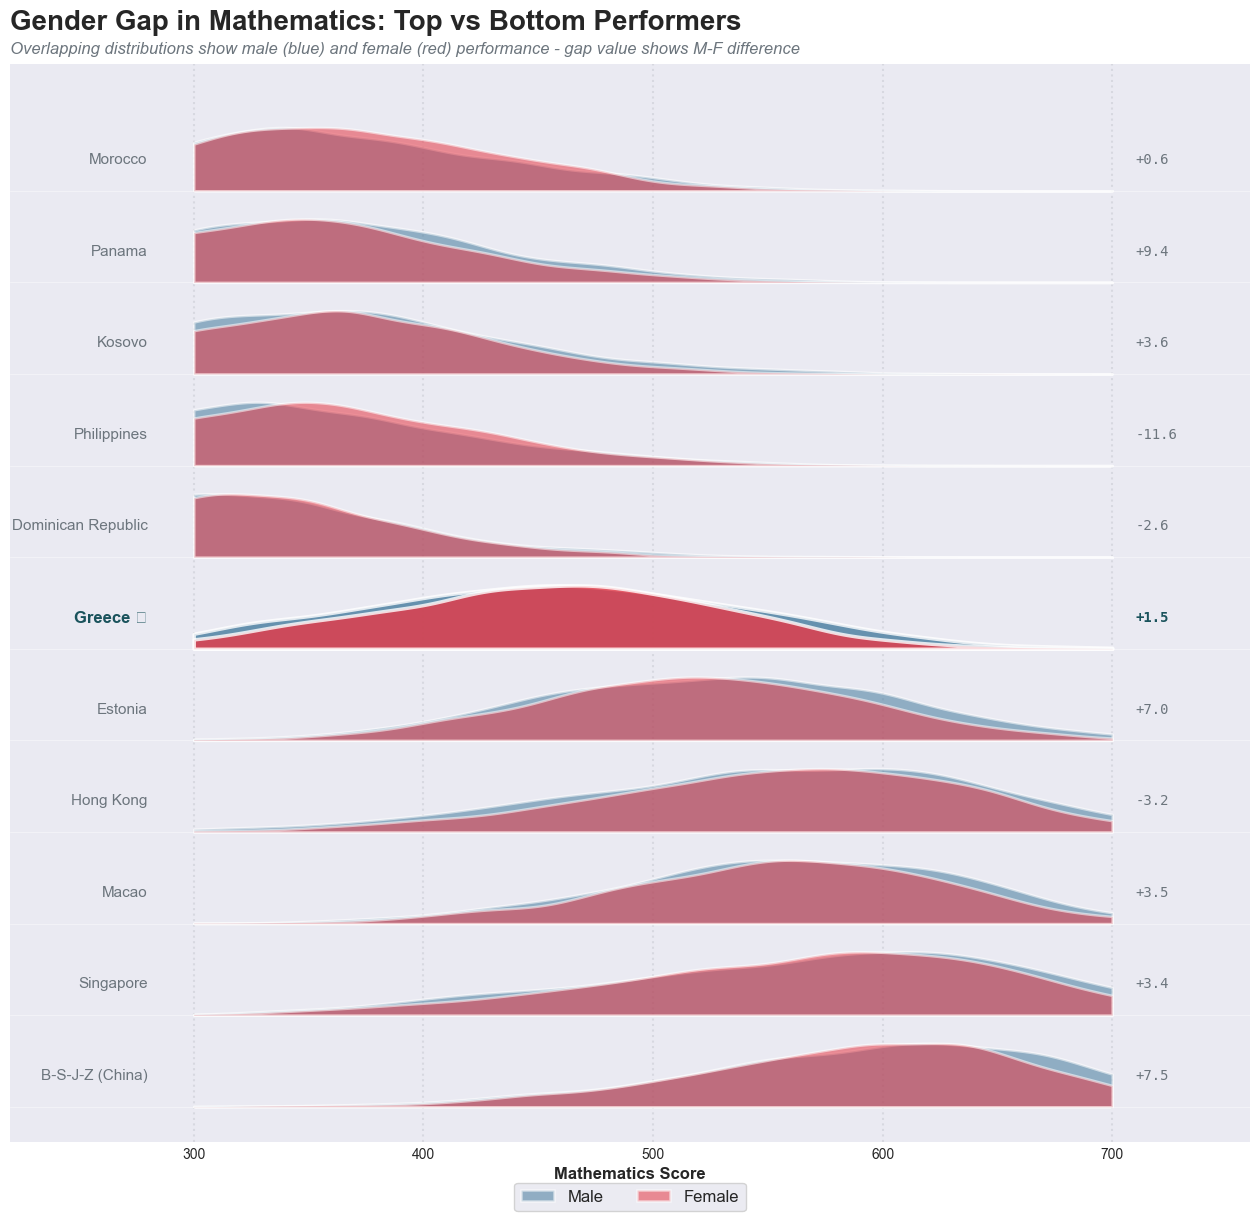

In [72]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(16, 14))

top_countries = country_means.nlargest(5, 'Average_Score').index.tolist()
bottom_countries = country_means.nsmallest(5, 'Average_Score').index.tolist()

if 'Greece' in country_means.index:
    selected_countries = top_countries + ['Greece'] + bottom_countries
else:
    selected_countries = top_countries + bottom_countries

selected_countries = [c for c in selected_countries if c in df['CNT'].values]
selected_countries = list(dict.fromkeys(selected_countries))

ridge_height = 0.9
spacing = 1.3
x_min, x_max = 300, 700

for i, country in enumerate(selected_countries):
    country_male = df[(df['CNT'] == country) & (df['ST004D01T'] == 'Male')]['MATH'].dropna()
    country_female = df[(df['CNT'] == country) & (df['ST004D01T'] == 'Female')]['MATH'].dropna()
    
    y_base = i * spacing
    
    is_greece = (country == 'Greece')
    alpha_val = 0.8 if is_greece else 0.55
    edge_width = 2.5 if is_greece else 1.8
    
    if len(country_male) > 50:
        kde_male = gaussian_kde(country_male)
        x_range = np.linspace(x_min, x_max, 500)
        density_male = kde_male(x_range)
        density_male_scaled = density_male / density_male.max() * ridge_height
        
        ax.fill_between(x_range, y_base, y_base + density_male_scaled, 
                       alpha=alpha_val, color='#457B9D', edgecolor='white', 
                       linewidth=edge_width, zorder=5, label='Male' if i == 0 else '')
    
    if len(country_female) > 50:
        kde_female = gaussian_kde(country_female)
        x_range = np.linspace(x_min, x_max, 500)
        density_female = kde_female(x_range)
        density_female_scaled = density_female / density_female.max() * ridge_height
        
        ax.fill_between(x_range, y_base, y_base + density_female_scaled, 
                       alpha=alpha_val, color='#E63946', edgecolor='white', 
                       linewidth=edge_width, zorder=6, label='Female' if i == 0 else '')
    
    ax.axhline(y=y_base, color='white', linewidth=0.8, alpha=0.4, zorder=3)
    
    country_label = f'{country} ★' if is_greece else country
    fontweight = 'bold' if is_greece else 'normal'
    fontsize = 12 if is_greece else 11
    label_color = '#1A535C' if is_greece else '#6C757D'
    
    ax.text(x_min - 20, y_base + ridge_height/2, country_label, 
           va='center', ha='right', fontsize=fontsize, fontweight=fontweight, 
           color=label_color, family='sans-serif')
    
    male_mean = country_male.mean()
    female_mean = country_female.mean()
    gap = male_mean - female_mean
    
    gap_color = '#1A535C' if is_greece else '#6C757D'
    ax.text(x_max + 10, y_base + ridge_height/2, f'{gap:+.1f}', 
           va='center', ha='left', fontsize=10, fontweight='bold' if is_greece else 'normal',
           color=gap_color, family='monospace')

ax.set_xlim(x_min - 80, x_max + 60)
ax.set_ylim(-0.5, len(selected_countries) * spacing + 0.5)

ax.set_xlabel('Mathematics Score', fontsize=12, fontweight='bold', family='sans-serif')
ax.set_ylabel('')
ax.set_title('Gender Gap in Mathematics: Top vs Bottom Performers', 
            fontsize=20, fontweight='bold', pad=25, loc='left', family='sans-serif')
ax.text(0, 1.01, 'Overlapping distributions show male (blue) and female (red) performance - gap value shows M-F difference', 
       transform=ax.transAxes, fontsize=12, style='italic', color='#6C757D')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.03), 
         ncol=2, frameon=True, framealpha=0.95, 
         fontsize=12, edgecolor='#D1D1D1', fancybox=True)

ax.set_yticks([])
ax.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1.5, color='#6C757D')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=True)
ax.tick_params(axis='x', labelsize=10, color='#6C757D')

# plt.tight_layout()
plt.show()

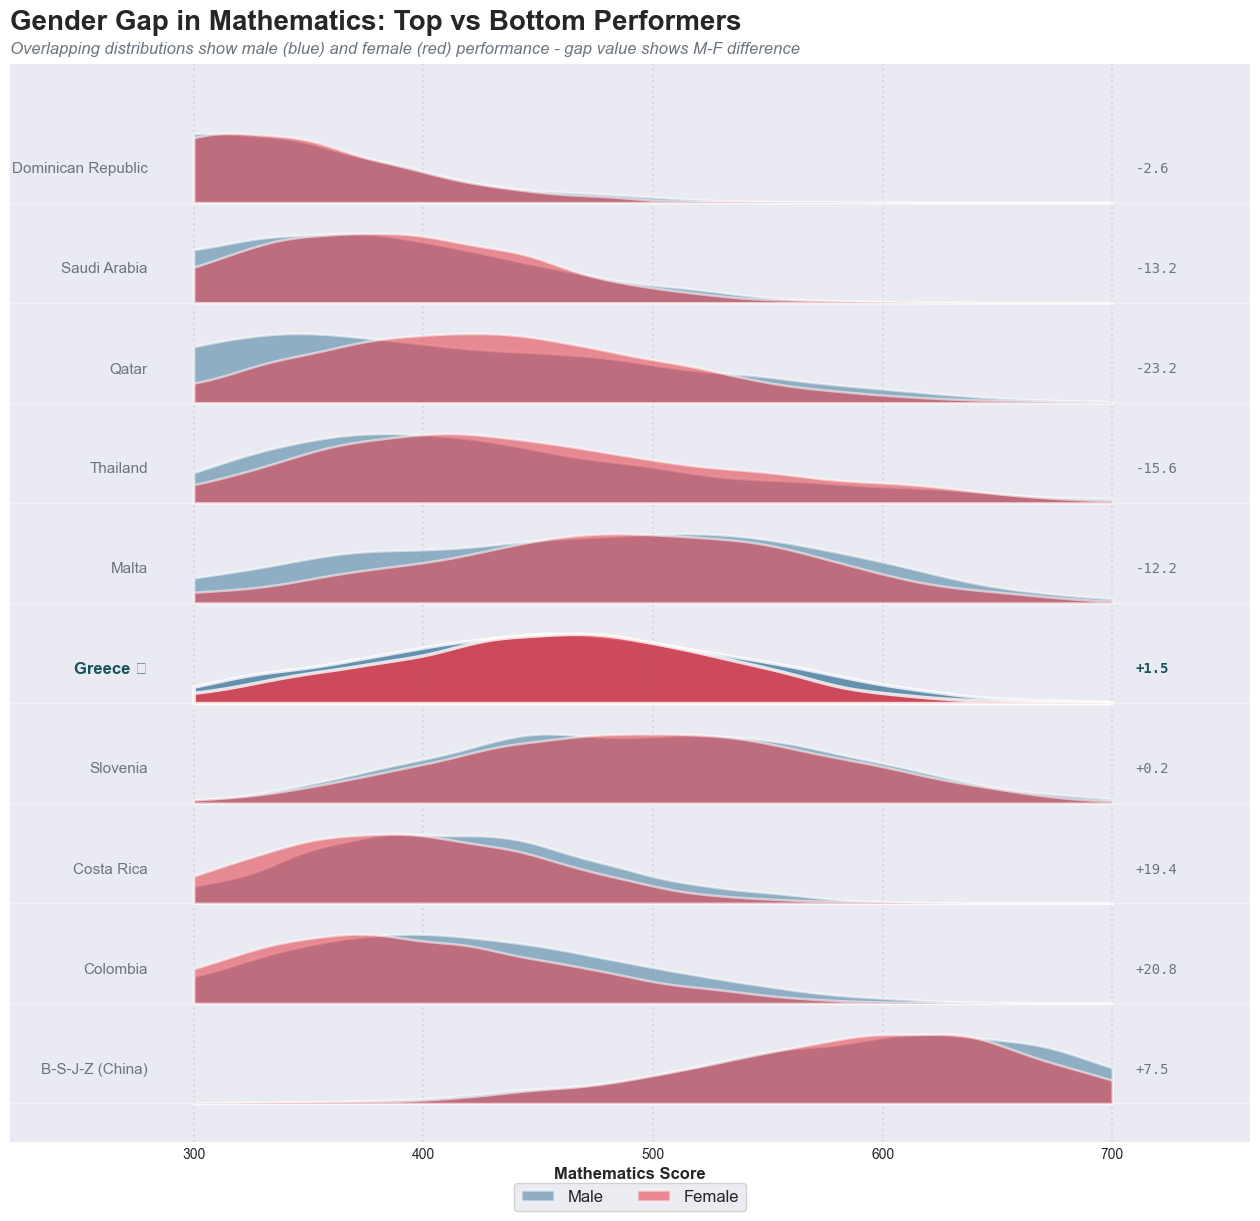

In [73]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(16, 14))

selected_countries = [
    'B-S-J-Z (China)',      # Top performer
    'Colombia',             # Largest gap (boys >>)
    'Costa Rica',           # Large gap (boys >>)
    'Slovenia',             # Most equal
    'Greece',               # Our focus
    'Malta',                # High perf + girls better
    'Thailand',             # Girls better
    'Qatar',                # Largest negative gap (girls >>)
    'Saudi Arabia',         # Girls better (cultural interest)
    'Dominican Republic'    # Bottom performer
]

selected_countries = [c for c in selected_countries if c in df['CNT'].values and c in gender_gaps.index]

ridge_height = 0.9
spacing = 1.3
x_min, x_max = 300, 700

for i, country in enumerate(selected_countries):
    country_male = df[(df['CNT'] == country) & (df['ST004D01T'] == 'Male')]['MATH'].dropna()
    country_female = df[(df['CNT'] == country) & (df['ST004D01T'] == 'Female')]['MATH'].dropna()
    
    y_base = i * spacing
    
    is_greece = (country == 'Greece')
    alpha_val = 0.8 if is_greece else 0.55
    edge_width = 2.5 if is_greece else 1.8
    
    if len(country_male) > 50:
        kde_male = gaussian_kde(country_male)
        x_range = np.linspace(x_min, x_max, 500)
        density_male = kde_male(x_range)
        density_male_scaled = density_male / density_male.max() * ridge_height
        
        ax.fill_between(x_range, y_base, y_base + density_male_scaled, 
                       alpha=alpha_val, color='#457B9D', edgecolor='white', 
                       linewidth=edge_width, zorder=5, label='Male' if i == 0 else '')
    
    if len(country_female) > 50:
        kde_female = gaussian_kde(country_female)
        x_range = np.linspace(x_min, x_max, 500)
        density_female = kde_female(x_range)
        density_female_scaled = density_female / density_female.max() * ridge_height
        
        ax.fill_between(x_range, y_base, y_base + density_female_scaled, 
                       alpha=alpha_val, color='#E63946', edgecolor='white', 
                       linewidth=edge_width, zorder=6, label='Female' if i == 0 else '')
    
    ax.axhline(y=y_base, color='white', linewidth=0.8, alpha=0.4, zorder=3)
    
    country_label = f'{country} ★' if is_greece else country
    fontweight = 'bold' if is_greece else 'normal'
    fontsize = 12 if is_greece else 11
    label_color = '#1A535C' if is_greece else '#6C757D'
    
    ax.text(x_min - 20, y_base + ridge_height/2, country_label, 
           va='center', ha='right', fontsize=fontsize, fontweight=fontweight, 
           color=label_color, family='sans-serif')
    
    male_mean = country_male.mean()
    female_mean = country_female.mean()
    gap = male_mean - female_mean
    
    gap_color = '#1A535C' if is_greece else '#6C757D'
    ax.text(x_max + 10, y_base + ridge_height/2, f'{gap:+.1f}', 
           va='center', ha='left', fontsize=10, fontweight='bold' if is_greece else 'normal',
           color=gap_color, family='monospace')

ax.set_xlim(x_min - 80, x_max + 60)
ax.set_ylim(-0.5, len(selected_countries) * spacing + 0.5)

ax.set_xlabel('Mathematics Score', fontsize=12, fontweight='bold', family='sans-serif')
ax.set_ylabel('')
ax.set_title('Gender Gap in Mathematics: Top vs Bottom Performers', 
            fontsize=20, fontweight='bold', pad=25, loc='left', family='sans-serif')
ax.text(0, 1.01, 'Overlapping distributions show male (blue) and female (red) performance - gap value shows M-F difference', 
       transform=ax.transAxes, fontsize=12, style='italic', color='#6C757D')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.03), 
         ncol=2, frameon=True, framealpha=0.95, 
         fontsize=12, edgecolor='#D1D1D1', fancybox=True)

ax.set_yticks([])
ax.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1.5, color='#6C757D')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=True)
ax.tick_params(axis='x', labelsize=10, color='#6C757D')

# plt.tight_layout()
plt.show()

### Plot Number 4

Top regional performer: Spain
Bottom regional performer: Albania


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/1818403984.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


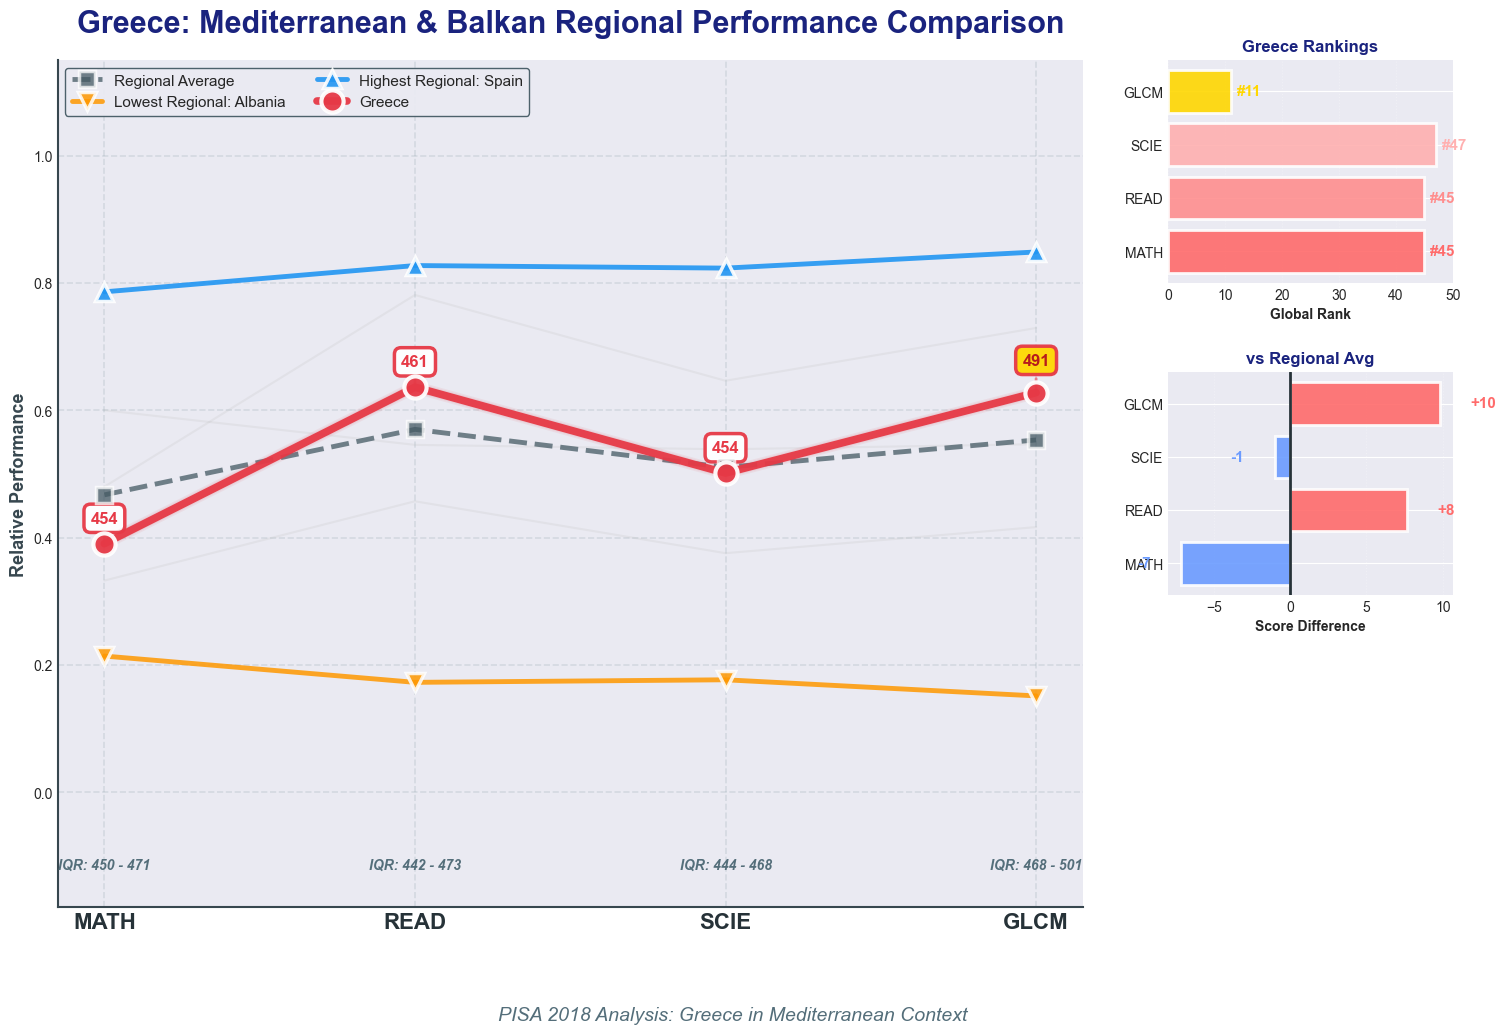


Greece vs Regional Performers:

Greece: {'MATH': 454.2, 'READ': 460.6, 'SCIE': 454.3, 'GLCM': 491.1}
Regional Average: {'MATH': 461.4, 'READ': 453.0, 'SCIE': 455.3, 'GLCM': 481.3}
Spain: {'MATH': 491.2, 'READ': 482.7, 'SCIE': 490.7, 'GLCM': 520.3}


In [74]:
# Create parallel coordinates with better visibility and quartile ranges
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)

# Main parallel coordinates plot
ax_main = fig.add_subplot(gs[:, :3])

# Get regional data
regional_countries = [
    'Greece', 'Italy', 'Spain', 'Portugal', 'Croatia', 
    'Bulgaria', 'Romania', 'Serbia', 'Albania', 'Turkey',
    'Cyprus', 'Malta', 'Slovenia'
]

available_regional = [c for c in regional_countries if c in country_means.index]
regional_data = country_means.loc[available_regional, ['MATH', 'READ', 'SCIE', 'GLCM']].copy()
regional_data = regional_data.dropna()


# Calculate regional average
regional_avg = regional_data.mean()

# Find top and bottom performers in the region
regional_avg_scores = regional_data[['MATH', 'READ', 'SCIE']].mean(axis=1)
top_regional = regional_avg_scores.idxmax()
bottom_regional = regional_avg_scores.idxmin()

print(f"Top regional performer: {top_regional}")
print(f"Bottom regional performer: {bottom_regional}")

# Add top/bottom regional performers to the data for normalization
display_data = regional_data.copy()

# Use extended range for normalization
regional_data_norm = pd.DataFrame(index=display_data.index, columns=SUBJECTS)
q25_vals = {}
q75_vals = {}

for subject in SUBJECTS:
    q25 = display_data[subject].quantile(0.25)
    q75 = display_data[subject].quantile(0.75)
    q25_vals[subject] = q25
    q75_vals[subject] = q75
    
    # Normalize using a wider range for better visibility
    min_val = display_data[subject].min() - 20
    max_val = display_data[subject].max() + 20
    regional_data_norm[subject] = (display_data[subject] - min_val) / (max_val - min_val)

# Normalize regional average
regional_avg_norm = pd.Series(index=SUBJECTS)
for subject in SUBJECTS:
    min_val = display_data[subject].min() - 20
    max_val = display_data[subject].max() + 20
    regional_avg_norm[subject] = (regional_avg[subject] - min_val) / (max_val - min_val)

positions = np.arange(len(SUBJECTS))

# Plot background countries with very light styling
for country in regional_data_norm.index:
    if country not in ['Greece', top_regional, bottom_regional]:
        values = regional_data_norm.loc[country].values
        ax_main.plot(positions, values, linewidth=1.5, alpha=0.2, 
                    color='#BDBDBD', zorder=2)

# Plot regional average line
ax_main.plot(positions, regional_avg_norm.values, 
            linewidth=3.5, linestyle='--', color='#455A64', alpha=0.75,
            marker='s', markersize=11, markeredgewidth=2.5, markeredgecolor='white',
            label='Regional Average', zorder=6)

# Plot bottom regional performer
if bottom_regional != 'Greece':
    bottom_values = regional_data_norm.loc[bottom_regional].values
    ax_main.plot(positions, bottom_values, 
                linewidth=3.5, color='#FF9800', alpha=0.85,
                marker='v', markersize=13, markeredgewidth=2.5, markeredgecolor='white',
                label=f'Lowest Regional: {bottom_regional}', zorder=7)

# Plot top regional performer
if top_regional != 'Greece':
    top_values = regional_data_norm.loc[top_regional].values
    ax_main.plot(positions, top_values, 
                linewidth=3.5, color='#2196F3', alpha=0.9,
                marker='^', markersize=13, markeredgewidth=2.5, markeredgecolor='white',
                label=f'Highest Regional: {top_regional}', zorder=8)

# Plot GREECE prominently
greece_values = regional_data_norm.loc['Greece'].values
ax_main.plot(positions, greece_values, 
            linewidth=5.5, color='#E63946', alpha=0.95,
            marker='o', markersize=16, markeredgewidth=3, markeredgecolor='white',
            label='Greece', zorder=10, solid_capstyle='round')

# Add subtle glow effect for Greece
for width in [7, 9]:
    ax_main.plot(positions, greece_values, linewidth=width, 
                color='#E63946', alpha=0.08, zorder=9)

# Annotate actual scores on Greece line - FIXED
for i, (pos, val) in enumerate(zip(positions, greece_values)):
    actual_score = display_data.loc['Greece', SUBJECTS[i]]
    rank = country_means[f'{SUBJECTS[i]}_Rank'].loc['Greece']
    
    if SUBJECTS[i] == 'GLCM':
        bbox_color = '#FFD700'
        text_color = '#B71C1C'
        offset_y = 20
    else:
        bbox_color = 'white'
        text_color = '#E63946'
        offset_y = 15
    
    ax_main.annotate(f'{actual_score:.0f}', 
                    xy=(pos, val), xytext=(0, offset_y), textcoords='offset points',
                    fontsize=12, fontweight='bold', color=text_color, ha='center',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor=bbox_color, 
                             edgecolor='#E63946', linewidth=2.5, alpha=0.95),
                    arrowprops=dict(arrowstyle='-', lw=2, color='#E63946', alpha=0.6))

# Styling
ax_main.set_xticks(positions)
ax_main.set_xticklabels(SUBJECTS, fontsize=16, fontweight='bold', color='#263238')
ax_main.set_ylabel('Relative Performance', fontsize=13, fontweight='bold', color='#37474F')
ax_main.set_title('Greece: Mediterranean & Balkan Regional Performance Comparison', 
                 fontsize=22, fontweight='bold', pad=20, color='#1A237E')

# Add IQR ranges below
for i, subject in enumerate(SUBJECTS):
    q25 = q25_vals[subject]
    q75 = q75_vals[subject]
    ax_main.text(i, -0.12, f'IQR: {q25:.0f} - {q75:.0f}', 
                ha='center', fontsize=10, color='#546E7A', 
                style='italic', weight='bold')

ax_main.set_ylim(-0.18, 1.15)
ax_main.grid(axis='both', alpha=0.25, linestyle='--', linewidth=1.2, color='#90A4AE')

# Legend
ax_main.legend(loc='upper left', fontsize=11, frameon=True, 
              framealpha=0.95, edgecolor='#455A64', fancybox=True,
              shadow=False, ncol=2)

for spine in ['top', 'right']:
    ax_main.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax_main.spines[spine].set_linewidth(1.5)
    ax_main.spines[spine].set_color('#37474F')

# Side panel 1: Rank comparison bars
ax_ranks = fig.add_subplot(gs[0, 3])
greece_ranks = [country_means.loc['Greece', f'{s}_Rank'] for s in SUBJECTS]
colors_rank = ['#FF6B6B', '#FF8E8E', '#FFB0B0', '#FFD700']

bars = ax_ranks.barh(SUBJECTS, greece_ranks, color=colors_rank, 
                     edgecolor='white', linewidth=2, alpha=0.9)
for i, (bar, rank) in enumerate(zip(bars, greece_ranks)):
    ax_ranks.text(rank + 1, i, f'#{int(rank)}', va='center', 
                 fontsize=11, fontweight='bold', color=colors_rank[i])

ax_ranks.set_xlim(50, 0)
ax_ranks.set_xlabel('Global Rank', fontsize=10, fontweight='bold')
ax_ranks.set_title('Greece Rankings', fontsize=12, fontweight='bold', color='#1A237E')
ax_ranks.grid(axis='x', alpha=0.3, linestyle=':')
ax_ranks.invert_xaxis()

# Side panel 2: Score differences from regional average
ax_diff = fig.add_subplot(gs[1, 3])
greece_scores = [display_data.loc['Greece', s] for s in SUBJECTS]
avg_scores = [regional_avg[s] for s in SUBJECTS]
differences = [g - a for g, a in zip(greece_scores, avg_scores)]

colors_diff = ['#FF6B6B' if d > 0 else '#6B9BFF' for d in differences]
bars2 = ax_diff.barh(SUBJECTS, differences, color=colors_diff, 
                     edgecolor='white', linewidth=2, alpha=0.9)
for i, (bar, diff) in enumerate(zip(bars2, differences)):
    ax_diff.text(diff + (2 if diff > 0 else -2), i, f'{diff:+.0f}', 
                va='center', ha='left' if diff > 0 else 'right',
                fontsize=11, fontweight='bold', color=colors_diff[i])

ax_diff.axvline(x=0, color='#263238', linewidth=2, linestyle='-')
ax_diff.set_xlabel('Score Difference', fontsize=10, fontweight='bold')
ax_diff.set_title('vs Regional Avg', fontsize=12, fontweight='bold', color='#1A237E')
ax_diff.grid(axis='x', alpha=0.3, linestyle=':')

plt.suptitle('PISA 2018 Analysis: Greece in Mediterranean Context', 
            fontsize=14, color='#546E7A', style='italic', y=0.02)

plt.tight_layout()
plt.show()

print("\nGreece vs Regional Performers:")
print(f"\nGreece: {display_data.loc['Greece'].round(1).to_dict()}")
print(f"Regional Average: {regional_avg.round(1).to_dict()}")
print(f"{top_regional}: {display_data.loc[top_regional].round(1).to_dict()}")

### Plot Number 5

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/968269599.py:207: UserWarning: Glyph 9473 (\N{BOX DRAWINGS HEAVY HORIZONTAL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/968269599.py:207: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/data_visualisation/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9473 (\N{BOX DRAWINGS HEAVY HORIZONTAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/data_visualisation/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


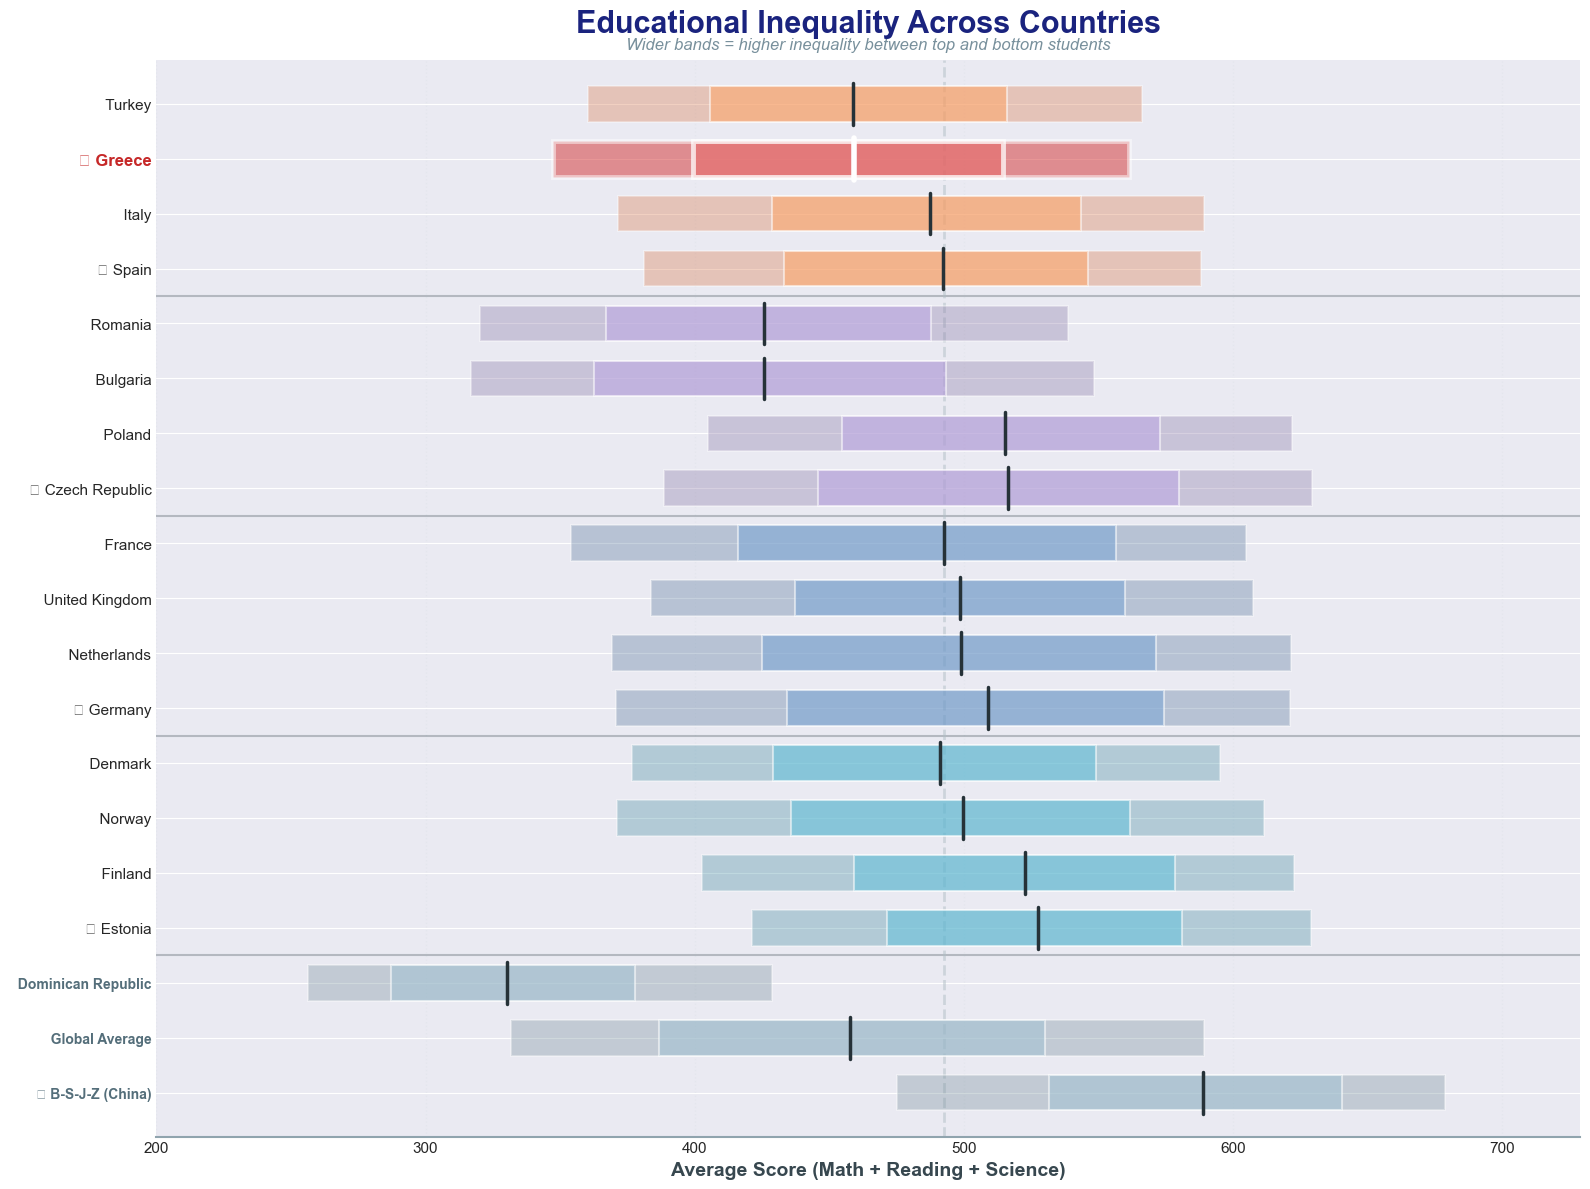


Greece: Median = 459, Inequality = 214


In [75]:
# Simplified focused version - fewer countries, clearer message
regions_config = {
    'Global Reference': {
        'countries': ['B-S-J-Z (China)', 'Global Average', 'Dominican Republic'],
        'color': '#78909C',
    },
    'Northern Europe': {
        'countries': ['Finland', 'Estonia', 'Denmark', 'Norway'],
        'color': '#4A90A4',
    },
    'Western Europe': {
        'countries': ['Germany', 'France', 'United Kingdom', 'Netherlands'],
        'color': '#5A7A9E',
    },
    'Eastern Europe': {
        'countries': ['Poland', 'Czech Republic', 'Romania', 'Bulgaria'],
        'color': '#8B7BA8',
    },
    'Mediterranean': {
        'countries': ['Greece', 'Italy', 'Spain', 'Turkey'],
        'color': '#D97B4E',
    }
}

# Calculate percentiles
percentile_data = []

def calculate_percentiles(student_data):
    if len(student_data) == 0:
        return None
    student_avg = student_data.mean(axis=1)
    return {
        'p10': np.percentile(student_avg, 10),
        'p25': np.percentile(student_avg, 25),
        'p50': np.percentile(student_avg, 50),
        'p75': np.percentile(student_avg, 75),
        'p90': np.percentile(student_avg, 90),
    }

for region_name, config in regions_config.items():
    for country in config['countries']:
        if country == 'Global Average':
            data = df[['MATH', 'READ', 'SCIE']].dropna()
        elif country in country_means.index:
            data = df[df['CNT'] == country][['MATH', 'READ', 'SCIE']].dropna()
        else:
            continue
        
        percentiles = calculate_percentiles(data)
        if percentiles:
            percentiles['Country'] = country
            percentiles['Region'] = region_name
            percentiles['color'] = config['color']
            percentiles['spread'] = percentiles['p90'] - percentiles['p10']
            percentiles['is_greece'] = (country == 'Greece')
            percentile_data.append(percentiles)

percentile_df = pd.DataFrame(percentile_data)

# Sort by region order, then by median within region
region_order = ['Global Reference', 'Northern Europe', 'Western Europe', 
                'Eastern Europe', 'Mediterranean']

sorted_dfs = []
for region in region_order:
    region_df = percentile_df[percentile_df['Region'] == region].copy()
    if len(region_df) > 0:
        region_df = region_df.sort_values('p50', ascending=False)
        sorted_dfs.append(region_df)

percentile_df = pd.concat(sorted_dfs, ignore_index=True)

# Create simplified plot
fig, ax = plt.subplots(figsize=(16, 12))

y_positions = np.arange(len(percentile_df))
global_median = percentile_df['p50'].median()

# Collect region boundaries
region_boundaries = {}
for region in region_order:
    region_mask = percentile_df['Region'] == region
    if region_mask.any():
        region_indices = percentile_df[region_mask].index
        first_idx = percentile_df.index.get_loc(region_indices[0])
        last_idx = percentile_df.index.get_loc(region_indices[-1])
        region_boundaries[region] = (y_positions[first_idx], y_positions[last_idx])

# Plot bars
for i, row in percentile_df.iterrows():
    y = y_positions[percentile_df.index.get_loc(i)]
    
    is_greece = row['is_greece']
    base_color = row['color']
    
    if is_greece:
        color_outer = '#D32F2F'
        color_mid = '#E57373'
        alpha_outer = 0.5
        alpha_mid = 0.75
        edge_width = 3.5
    else:
        color_outer = base_color
        rgb = mcolors.hex2color(base_color)
        lighter = tuple(min(1, c * 1.35) for c in rgb)
        color_mid = mcolors.rgb2hex(lighter)
        alpha_outer = 0.35
        alpha_mid = 0.55
        edge_width = 1.5
    
    # Wide band (10-90)
    ax.barh(y, row['p90'] - row['p10'], left=row['p10'], height=0.65,
           color=color_outer, alpha=alpha_outer, edgecolor='white', 
           linewidth=edge_width, zorder=3)
    
    # Narrow band (25-75)
    ax.barh(y, row['p75'] - row['p25'], left=row['p25'], height=0.65,
           color=color_mid, alpha=alpha_mid, edgecolor='white', 
           linewidth=edge_width, zorder=4)
    
    # Median line
    median_color = 'white' if is_greece else '#263238'
    median_width = 4 if is_greece else 2.5
    ax.plot([row['p50'], row['p50']], [y - 0.38, y + 0.38],
           color=median_color, linewidth=median_width, 
           zorder=5, solid_capstyle='round')

# Add clean region separators
for i, region in enumerate(region_order):
    if region in region_boundaries and i > 0:
        y_start, _ = region_boundaries[region]
        ax.axhline(y=y_start - 0.5, color='#37474F', linewidth=1.5, 
                  alpha=0.3, zorder=1)

# Global median reference
ax.axvline(x=global_median, color='#B0BEC5', linestyle='--', 
          linewidth=2, alpha=0.5, zorder=2)

# Country labels with region prefixes
ax.set_yticks(y_positions)
country_labels = []
prev_region = None

for _, row in percentile_df.iterrows():
    country = row['Country']
    region = row['Region']
    
    # Add region header before first country
    if region != prev_region:
        if region == 'Global Reference':
            prefix = "━ "
        elif region == 'Mediterranean':
            prefix = "━ "
        elif region == 'Northern Europe':
            prefix = "━ "
        elif region == 'Western Europe':
            prefix = "━ "
        elif region == 'Eastern Europe':
            prefix = "━ "
        prev_region = region
    else:
        prefix = "  "
    
    if row['is_greece']:
        country_labels.append(f"{prefix}★ {country}")
    else:
        country_labels.append(f"{prefix}{country}")

ax.set_yticklabels(country_labels, fontsize=11)

# Style labels
for label, row in zip(ax.get_yticklabels(), percentile_df.itertuples()):
    if row.is_greece:
        label.set_color('#C62828')
        label.set_fontweight('bold')
        label.set_fontsize(12)
    elif row.Region == 'Global Reference':
        label.set_color('#546E7A')
        label.set_fontweight('bold')
        label.set_fontsize(10)

# Simple title
ax.set_xlabel('Average Score (Math + Reading + Science)', 
             fontsize=14, fontweight='bold', color='#37474F')
ax.set_title('Educational Inequality Across Countries', 
            fontsize=22, fontweight='bold', pad=20, color='#1A237E')

# Minimal subtitle
ax.text(0.5, 1.01, 'Wider bands = higher inequality between top and bottom students', 
       transform=ax.transAxes, fontsize=12, style='italic', 
       color='#78909C', ha='center')

# Styling
ax.set_xlim(200, max(percentile_df['p90']) + 50)
ax.set_ylim(-0.8, len(y_positions) - 0.2)

ax.grid(axis='x', alpha=0.2, linestyle=':', linewidth=1, color='#CFD8DC')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['bottom'].set_color('#90A4AE')

ax.tick_params(left=False, bottom=True)
ax.tick_params(axis='x', labelsize=11, color='#78909C')

plt.tight_layout()
plt.show()

# Simple summary
greece_row = percentile_df[percentile_df['Country'] == 'Greece'].iloc[0]
print(f"\nGreece: Median = {greece_row['p50']:.0f}, Inequality = {greece_row['spread']:.0f}")

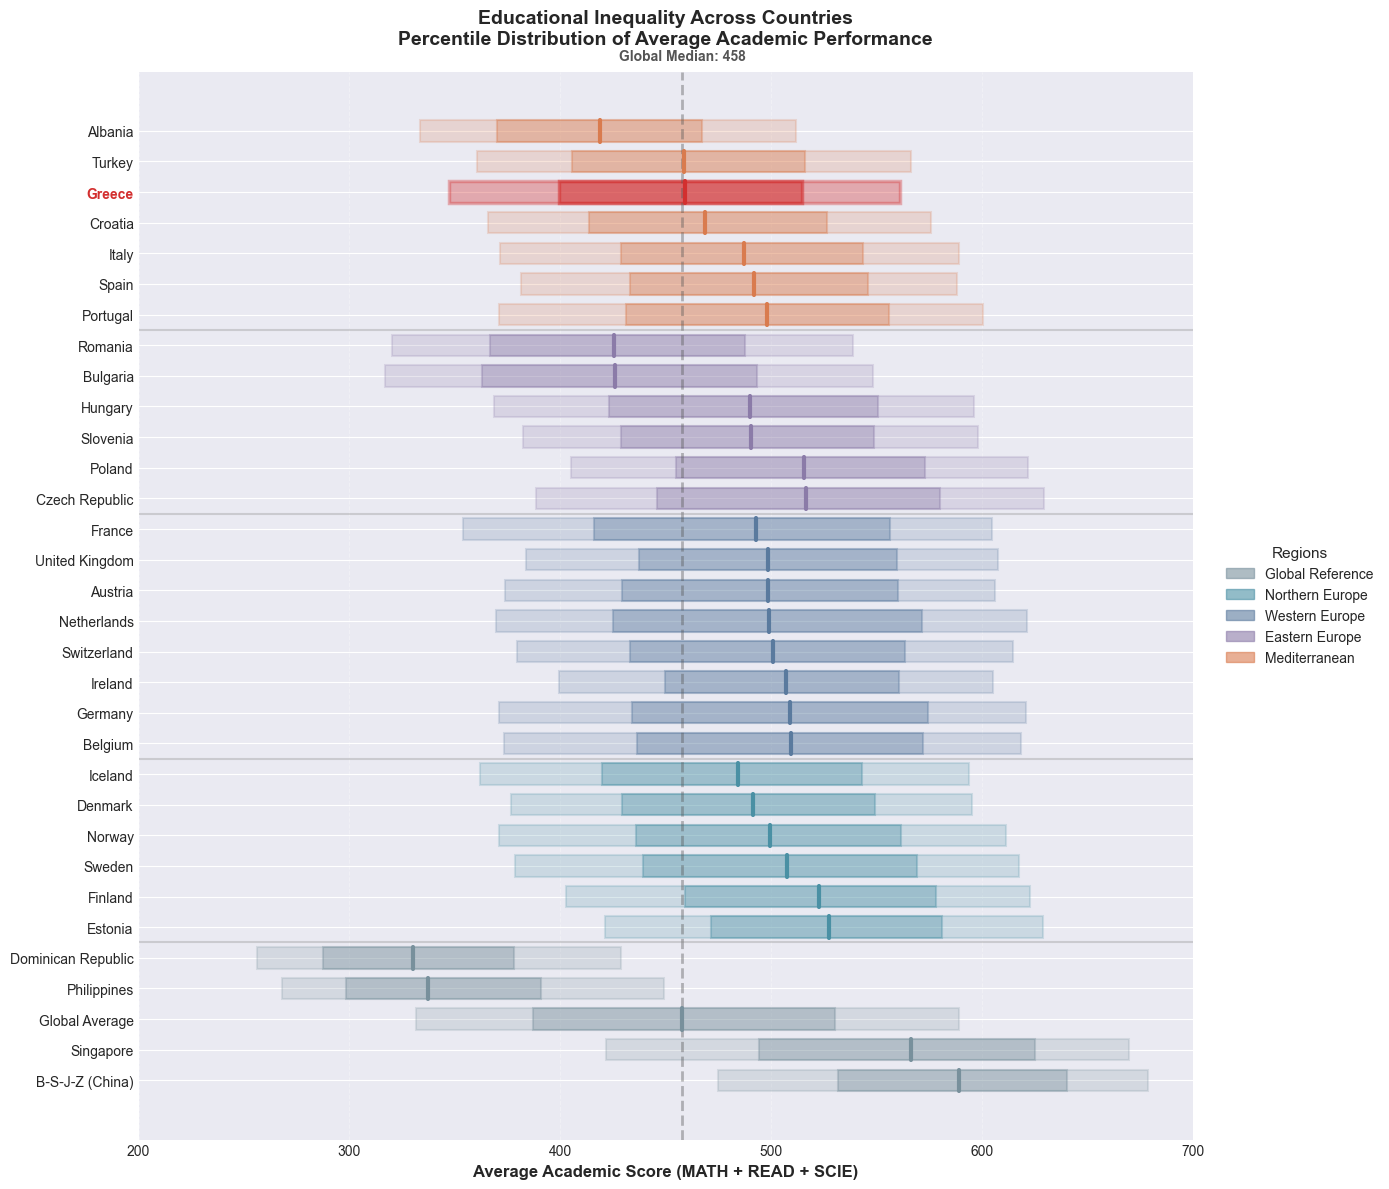

In [76]:
# Calculate average academic score (MATH + READ + SCIE)
df['AVG_ACADEMIC'] = df[['MATH', 'READ', 'SCIE']].mean(axis=1)

# Define regions with their countries and colors
regions_config = {
    'Global Reference': {
        'countries': ['B-S-J-Z (China)', 'Singapore', 'Global Average', 'Dominican Republic', 'Philippines'],
        'color': '#78909C'
    },
    'Northern Europe': {
        'countries': ['Finland', 'Estonia', 'Sweden', 'Denmark', 'Norway', 'Iceland'],
        'color': '#4A90A4'
    },
    'Western Europe': {
        'countries': ['Netherlands', 'Belgium', 'Switzerland', 'Germany', 'France', 'United Kingdom', 'Ireland', 'Austria'],
        'color': '#5A7A9E'
    },
    'Eastern Europe': {
        'countries': ['Poland', 'Czech Republic', 'Slovenia', 'Hungary', 'Slovakia', 'Romania', 'Bulgaria'],
        'color': '#8B7BA8'
    },
    'Mediterranean': {
        'countries': ['Greece', 'Italy', 'Spain', 'Portugal', 'Croatia', 'Turkey', 'Albania'],
        'color': '#D97B4E'
    }
}

# Flatten to create country-to-region and country-to-color mappings
country_to_region = {}
country_to_color = {}
for region, config in regions_config.items():
    for country in config['countries']:
        country_to_region[country] = region
        country_to_color[country] = config['color']

# Calculate percentiles
selected_countries = [c for region_data in regions_config.values() for c in region_data['countries'] if c != 'Global Average']
percentile_data = []

for country in selected_countries:
    country_data = df[df['CNT'] == country]['AVG_ACADEMIC'].dropna()
    if len(country_data) > 0:
        percentiles = {
            'Country': country,
            '10th': np.percentile(country_data, 10),
            '25th': np.percentile(country_data, 25),
            '50th': np.percentile(country_data, 50),
            '75th': np.percentile(country_data, 75),
            '90th': np.percentile(country_data, 90),
            'Region': country_to_region[country],
            'Color': country_to_color[country]
        }
        percentile_data.append(percentiles)

# Add global average
all_scores = df['AVG_ACADEMIC'].dropna()
global_avg = {
    'Country': 'Global Average',
    '10th': np.percentile(all_scores, 10),
    '25th': np.percentile(all_scores, 25),
    '50th': np.percentile(all_scores, 50),
    '75th': np.percentile(all_scores, 75),
    '90th': np.percentile(all_scores, 90),
    'Region': 'Global Reference',
    'Color': country_to_color['Global Average']
}
percentile_data.append(global_avg)

df_percentiles = pd.DataFrame(percentile_data)
df_percentiles['Spread'] = df_percentiles['90th'] - df_percentiles['10th']

# Group by region instead of sorting by median
region_order = ['Global Reference', 'Northern Europe', 'Western Europe', 'Eastern Europe', 'Mediterranean']
df_percentiles['Region'] = pd.Categorical(df_percentiles['Region'], categories=region_order, ordered=True)
df_percentiles = df_percentiles.sort_values(['Region', '50th'], ascending=[True, False]).reset_index(drop=True)

# Create plot
fig, ax = plt.subplots(figsize=(14, 12))

# Plot ribbons
for idx, row in df_percentiles.iterrows():
    y_pos = idx
    color = row['Color']
    
    if row['Country'] == 'Greece':
        color = '#D32F2F'
        alpha_outer = 0.35
        alpha_inner = 0.55
        linewidth = 2.5
    else:
        alpha_outer = 0.20
        alpha_inner = 0.35
        linewidth = 1.5
    
    # Outer ribbon (10th-90th percentile)
    ax.barh(y_pos, row['90th'] - row['10th'], left=row['10th'], 
            height=0.7, color=color, alpha=alpha_outer, edgecolor=color, linewidth=linewidth)
    
    # Inner ribbon (25th-75th percentile)
    ax.barh(y_pos, row['75th'] - row['25th'], left=row['25th'], 
            height=0.7, color=color, alpha=alpha_inner, edgecolor=color, linewidth=linewidth)
    
    # Median line
    ax.plot([row['50th'], row['50th']], [y_pos - 0.35, y_pos + 0.35], 
            color=color, linewidth=3, zorder=3)

# Add region separators
current_region = None
for idx, row in df_percentiles.iterrows():
    if row['Region'] != current_region:
        if current_region is not None:
            ax.axhline(idx - 0.5, color='gray', linestyle='-', linewidth=1.5, alpha=0.3)
        current_region = row['Region']

# Country labels
country_labels = []
for idx, row in df_percentiles.iterrows():
    if row['Country'] == 'Greece':
        country_labels.append('Greece')
    else:
        country_labels.append(row['Country'])

ax.set_yticks(range(len(df_percentiles)))
ax.set_yticklabels(country_labels, fontsize=10)

# Highlight Greece label
ytick_labels = ax.get_yticklabels()
for label in ytick_labels:
    if 'Greece' in label.get_text():
        label.set_color('#D32F2F')
        label.set_fontweight('bold')

# Add global median reference line
global_median = df_percentiles[df_percentiles['Country'] == 'Global Average']['50th'].values[0]
ax.axvline(global_median, color='#555555', linestyle='--', linewidth=2, alpha=0.4, zorder=1)
ax.text(global_median, len(df_percentiles) + 1.2, f'Global Median: {global_median:.0f}', 
        ha='center', va='bottom', fontsize=10, color='#555555', fontweight='bold')

# Create legend outside the plot
legend_elements = []
for region in region_order:
    legend_elements.append(Patch(facecolor=regions_config[region]['color'], 
                                 edgecolor=regions_config[region]['color'],
                                 label=region, alpha=0.6))

ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), 
          fontsize=10, title='Regions', title_fontsize=11, framealpha=0.95)

# Formatting
ax.set_xlabel('Average Academic Score (MATH + READ + SCIE)', fontsize=12, fontweight='bold')
ax.set_title('Educational Inequality Across Countries\nPercentile Distribution of Average Academic Performance', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(200, 700)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Plot Number 6

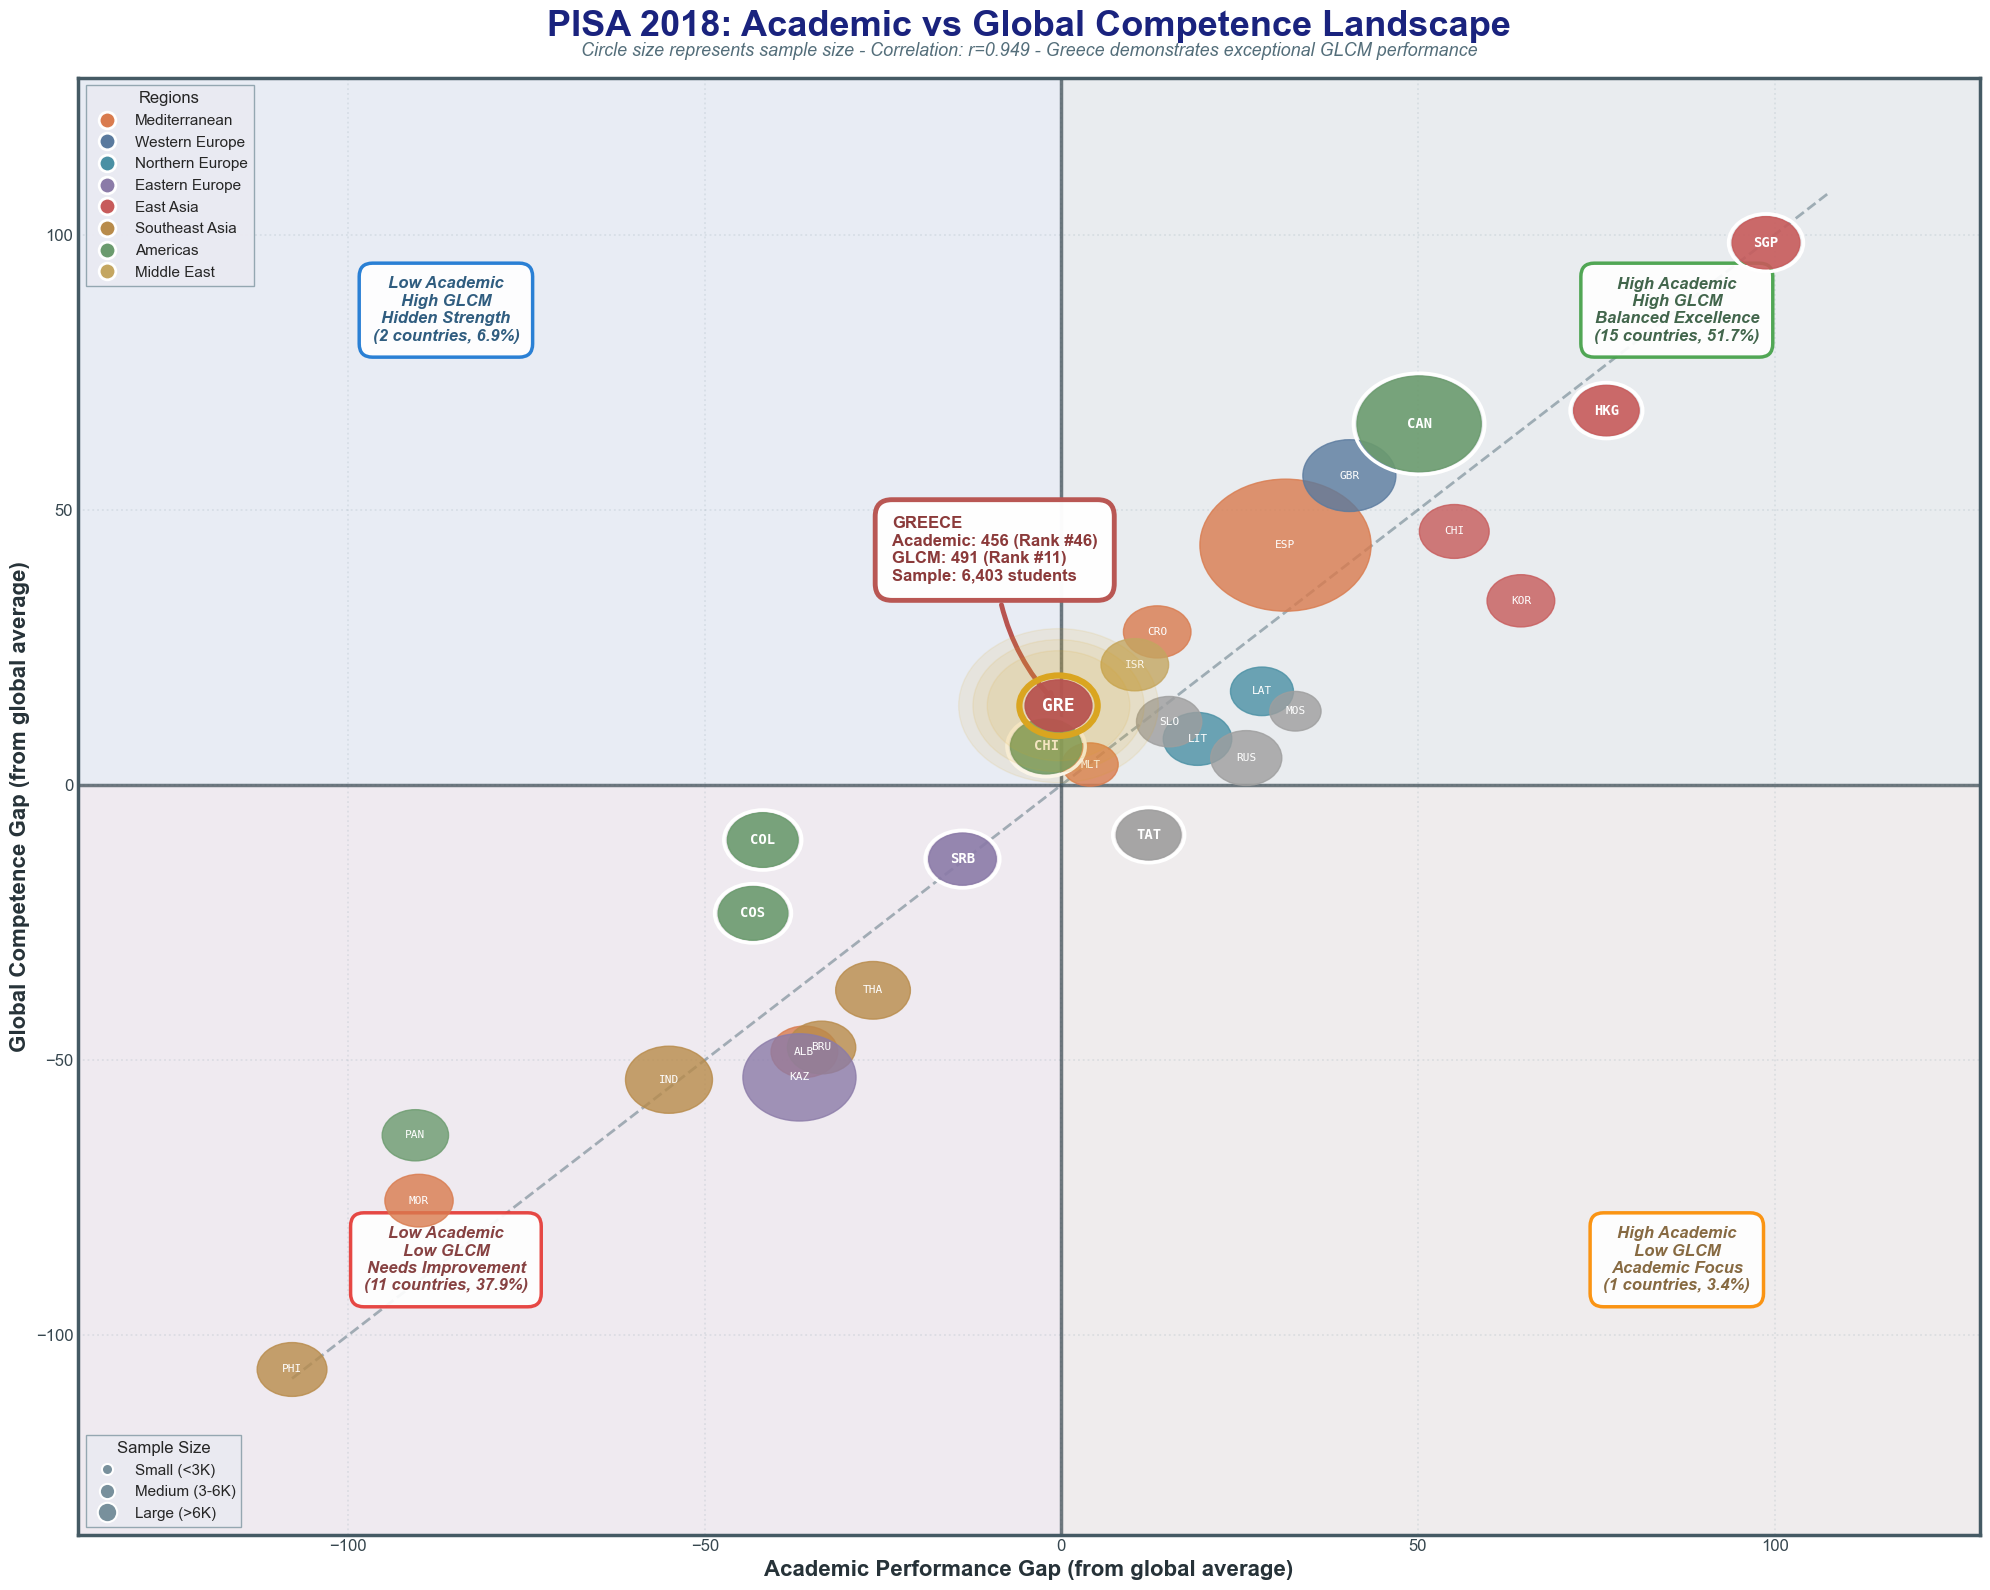


Correlation: r = 0.949
Greece: Academic -0.4, GLCM +14.4


In [77]:

# Regional color mapping - CLEAR BUT PROFESSIONAL
def get_region_and_color(country):
    """Get region and color - clear distinction, professional palette"""
    regions = {
        'Mediterranean': {
            'countries': ['Greece', 'Italy', 'Spain', 'Portugal', 'Cyprus', 'Malta', 
                         'Croatia', 'Albania', 'Turkey', 'Morocco', 'Tunisia', 
                         'North Macedonia', 'Montenegro', 'Bosnia and Herzegovina'],
            'color': '#D97B4E'  # Terracotta/clay
        },
        'Western Europe': {
            'countries': ['France', 'Germany', 'United Kingdom', 'Belgium', 'Netherlands',
                         'Austria', 'Switzerland', 'Luxembourg', 'Ireland'],
            'color': '#5A7A9E'  # Medium blue-gray
        },
        'Northern Europe': {
            'countries': ['Finland', 'Sweden', 'Norway', 'Denmark', 'Iceland', 
                         'Estonia', 'Latvia', 'Lithuania'],
            'color': '#4A90A4'  # Nordic blue
        },
        'Eastern Europe': {
            'countries': ['Poland', 'Czech Republic', 'Slovakia', 'Hungary', 'Romania',
                         'Bulgaria', 'Serbia', 'Slovenia', 'Russia', 'Ukraine', 
                         'Moldova', 'Georgia', 'Kazakhstan'],
            'color': '#8B7BA8'  # Muted lavender
        },
        'East Asia': {
            'countries': ['B-S-J-Z (China)', 'Japan', 'Korea', 'Hong Kong', 'Macao', 
                         'Singapore', 'Chinese Taipei'],
            'color': '#C75B5B'  # Dusty red
        },
        'Southeast Asia': {
            'countries': ['Thailand', 'Vietnam', 'Malaysia', 'Indonesia', 'Philippines',
                         'Brunei Darussalam'],
            'color': '#B88B4A'  # Warm gold
        },
        'Americas': {
            'countries': ['United States', 'Canada', 'Mexico', 'Brazil', 'Argentina',
                         'Chile', 'Colombia', 'Peru', 'Uruguay', 'Costa Rica', 
                         'Panama', 'Dominican Republic'],
            'color': '#6B9B6E'  # Sage green
        },
        'Middle East': {
            'countries': ['Saudi Arabia', 'Qatar', 'United Arab Emirates', 'Jordan',
                         'Lebanon', 'Israel', 'Baku (Azerbaijan)'],
            'color': '#C4A661'  # Sandy gold
        },
        'Oceania': {
            'countries': ['Australia', 'New Zealand'],
            'color': '#5B9AAA'  # Teal
        },
    }
    
    for region, info in regions.items():
        if country in info['countries']:
            return region, info['color']
    return 'Other', '#9E9E9E'

def get_country_code(country_name):
    """Get 2-3 letter country code"""
    codes = {
        'Greece': 'GRE', 'Albania': 'ALB', 'Italy': 'ITA', 'Spain': 'ESP',
        'Portugal': 'POR', 'Croatia': 'CRO', 'Bulgaria': 'BUL', 'Romania': 'ROM',
        'Serbia': 'SRB', 'Turkey': 'TUR', 'Cyprus': 'CYP', 'Malta': 'MLT',
        'Slovenia': 'SVN', 'Finland': 'FIN', 'Singapore': 'SGP', 'United States': 'USA',
        'B-S-J-Z (China)': 'CHN', 'Hong Kong': 'HKG', 'Macao': 'MAC', 'Japan': 'JPN',
        'Korea': 'KOR', 'Estonia': 'EST', 'Poland': 'POL', 'Germany': 'GER',
        'France': 'FRA', 'United Kingdom': 'GBR', 'Netherlands': 'NED', 'Belgium': 'BEL',
        'Austria': 'AUT', 'Switzerland': 'SUI', 'Norway': 'NOR', 'Sweden': 'SWE',
        'Denmark': 'DEN', 'Canada': 'CAN', 'Australia': 'AUS', 'New Zealand': 'NZL',
    }
    return codes.get(country_name, country_name[:3].upper())

# Create plot
fig, ax = plt.subplots(figsize=(20, 16))

# Calculate metrics
plot_countries = country_means.dropna()
sample_sizes = country_stats.loc[plot_countries.index, 'Total_Students']

# X-axis: Academic Performance
academic_scores = plot_countries[['MATH', 'READ', 'SCIE']].mean(axis=1)
global_academic_mean = academic_scores.mean()
x_values = academic_scores - global_academic_mean

# Y-axis: GLCM Performance
glcm_scores = plot_countries['GLCM']
global_glcm_mean = glcm_scores.mean()
y_values = glcm_scores - global_glcm_mean

# Calculate correlation
correlation = np.corrcoef(x_values, y_values)[0, 1]

# Background
max_range = max(abs(x_values.min()), abs(x_values.max()), 
                abs(y_values.min()), abs(y_values.max()))

# Very subtle quadrant shading
ax.add_patch(Rectangle((0, 0), max_range + 30, max_range + 30, 
                       facecolor='#E8F5E9', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((-max_range - 30, 0), max_range + 30, max_range + 30, 
                       facecolor='#E3F2FD', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((0, -max_range - 30), max_range + 30, max_range + 30, 
                       facecolor='#FFF3E0', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((-max_range - 30, -max_range - 30), max_range + 30, max_range + 30, 
                       facecolor='#FFEBEE', alpha=0.25, zorder=0))

# Reference lines
ax.axhline(y=0, color='#37474F', linewidth=2.5, zorder=1, alpha=0.7)
ax.axvline(x=0, color='#37474F', linewidth=2.5, zorder=1, alpha=0.7)
ax.plot([-max_range, max_range], [-max_range, max_range], 
        linestyle='--', color='#546E7A', linewidth=2, alpha=0.5, zorder=1)

# Find top performers
quadrants = {
    'top_right': ((x_values > 0) & (y_values > 0)),
    'top_left': ((x_values < 0) & (y_values > 0)),
    'bottom_right': ((x_values > 0) & (y_values < 0)),
    'bottom_left': ((x_values < 0) & (y_values < 0))
}

top_per_quadrant = {}
for quad_name, mask in quadrants.items():
    if mask.sum() > 0:
        quad_y = y_values[mask]
        top_performers = quad_y.nlargest(3).index.tolist()
        top_per_quadrant[quad_name] = top_performers

# Normalize sample sizes
min_sample = sample_sizes.min()
max_sample = sample_sizes.max()

# Plot countries
for country in plot_countries.index:
    x = x_values[country]
    y = y_values[country]
    code = get_country_code(country)
    region, color = get_region_and_color(country)
    
    # Size based on sample
    sample_size = sample_sizes[country]
    normalized_size = ((sample_size - min_sample) / (max_sample - min_sample)) * 0.7 + 0.3
    circle_size = normalized_size * 12
    
    is_top = any(country in performers for performers in top_per_quadrant.values())
    is_greece = (country == 'Greece')
    
    if is_greece:
        # Greece - warm burgundy with gold accent
        for glow_size in [14, 12, 10]:
            circle = plt.Circle((x, y), glow_size, color='#DAA520', alpha=0.1, zorder=11)
            ax.add_patch(circle)
        circle = plt.Circle((x, y), circle_size, color='#B85450', alpha=0.95, zorder=13)
        ax.add_patch(circle)
        circle_border = plt.Circle((x, y), circle_size + 0.8, color='#DAA520', fill=False, 
                                  linewidth=4.5, zorder=14)
        ax.add_patch(circle_border)
        ax.text(x, y, code, ha='center', va='center', 
               fontsize=13, fontweight='bold', color='white', 
               zorder=15, family='monospace')
    elif is_top:
        circle = plt.Circle((x, y), circle_size, color=color, alpha=0.9, zorder=9)
        ax.add_patch(circle)
        circle_border = plt.Circle((x, y), circle_size + 0.5, color='#FFFFFF', fill=False, 
                                  linewidth=2.5, zorder=10)
        ax.add_patch(circle_border)
        ax.text(x, y, code, ha='center', va='center', 
               fontsize=10, fontweight='bold', color='white', 
               zorder=10, family='monospace')
    else:
        circle = plt.Circle((x, y), circle_size, color=color, alpha=0.8, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, code, ha='center', va='center', 
               fontsize=8, fontweight='normal', color='white', 
               zorder=6, family='monospace')

# Annotate Greece
greece_x = x_values['Greece']
greece_y = y_values['Greece']
ax.annotate(f'GREECE\nAcademic: {academic_scores["Greece"]:.0f} (Rank #{int(country_means.loc["Greece", "Average_Score_Rank"])})\nGLCM: {glcm_scores["Greece"]:.0f} (Rank #{int(country_means.loc["Greece", "GLCM_Rank"])})\nSample: {sample_sizes["Greece"]:,} students', 
           xy=(greece_x, greece_y), xytext=(-120, 90), textcoords='offset points',
           fontsize=12, fontweight='bold', color='#8B3A3A',
           bbox=dict(boxstyle='round,pad=1', facecolor='white', 
                    edgecolor='#B85450', linewidth=3.5, alpha=0.98),
           arrowprops=dict(arrowstyle='->', lw=3.5, color='#B85450',
                          connectionstyle='arc3,rad=0.2'))

# Quadrant statistics
quad_stats = {}
for quad_name, mask in quadrants.items():
    count = mask.sum()
    pct = (count / len(plot_countries)) * 100
    quad_stats[quad_name] = {'count': count, 'pct': pct}

# Quadrant labels
label_offset = max_range * 0.8
ax.text(label_offset, label_offset, 
       f'High Academic\nHigh GLCM\nBalanced Excellence\n({quad_stats["top_right"]["count"]} countries, {quad_stats["top_right"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=12, fontweight='bold', 
       color='#2E5539', alpha=0.9, style='italic',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.92, edgecolor='#43A047', linewidth=2.5))

ax.text(-label_offset, label_offset, 
       f'Low Academic\nHigh GLCM\nHidden Strength\n({quad_stats["top_left"]["count"]} countries, {quad_stats["top_left"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=12, fontweight='bold', 
       color='#1A4C72', alpha=0.9, style='italic',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.92, edgecolor='#1976D2', linewidth=2.5))

ax.text(label_offset, -label_offset, 
       f'High Academic\nLow GLCM\nAcademic Focus\n({quad_stats["bottom_right"]["count"]} countries, {quad_stats["bottom_right"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=12, fontweight='bold', 
       color='#7A5A2E', alpha=0.9, style='italic',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.92, edgecolor='#FB8C00', linewidth=2.5))

ax.text(-label_offset, -label_offset, 
       f'Low Academic\nLow GLCM\nNeeds Improvement\n({quad_stats["bottom_left"]["count"]} countries, {quad_stats["bottom_left"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=12, fontweight='bold', 
       color='#7A2E2E', alpha=0.9, style='italic',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.92, edgecolor='#E53935', linewidth=2.5))

# Styling
ax.set_xlabel('Academic Performance Gap (from global average)', 
             fontsize=16, fontweight='bold', color='#263238')
ax.set_ylabel('Global Competence Gap (from global average)', 
             fontsize=16, fontweight='bold', color='#263238')
ax.set_title('PISA 2018: Academic vs Global Competence Landscape', 
            fontsize=26, fontweight='bold', pad=30, color='#1A237E')
ax.text(0.5, 1.015, f'Circle size represents sample size - Correlation: r={correlation:.3f} - Greece demonstrates exceptional GLCM performance', 
       transform=ax.transAxes, fontsize=13, style='italic', 
       color='#546E7A', ha='center')

# Limits
padding = 30
ax.set_xlim(x_values.min() - padding, x_values.max() + padding)
ax.set_ylim(y_values.min() - padding, y_values.max() + padding)

ax.grid(True, alpha=0.2, linestyle=':', linewidth=1.3, color='#90A4AE')

for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color('#455A64')

ax.tick_params(labelsize=12, colors='#37474F', width=1.5)

# Clear legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D97B4E', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Mediterranean', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5A7A9E', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Western Europe', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4A90A4', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Northern Europe', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B7BA8', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Eastern Europe', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C75B5B', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='East Asia', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#B88B4A', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Southeast Asia', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#6B9B6E', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Americas', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C4A661', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Middle East', linestyle='None'),
]

legend1 = ax.legend(handles=legend_elements, loc='upper left', fontsize=11, 
                   frameon=True, framealpha=0.95, edgecolor='#90A4AE', 
                   fancybox=False, title='Regions', title_fontsize=12)

# Size legend
size_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#78909C', 
           markersize=8, markeredgecolor='white', markeredgewidth=1.5, 
           label='Small (<3K)', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#78909C', 
           markersize=11, markeredgecolor='white', markeredgewidth=1.5, 
           label='Medium (3-6K)', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#78909C', 
           markersize=14, markeredgecolor='white', markeredgewidth=1.5, 
           label='Large (>6K)', linestyle='None'),
]

legend2 = ax.legend(handles=size_elements, loc='lower left', fontsize=11, 
                   frameon=True, framealpha=0.95, edgecolor='#90A4AE', 
                   fancybox=False, title='Sample Size', title_fontsize=12)

ax.add_artist(legend1)

plt.tight_layout()
plt.show()

print(f"\nCorrelation: r = {correlation:.3f}")
print(f"Greece: Academic {greece_x:+.1f}, GLCM {greece_y:+.1f}")

### Plot Number 7

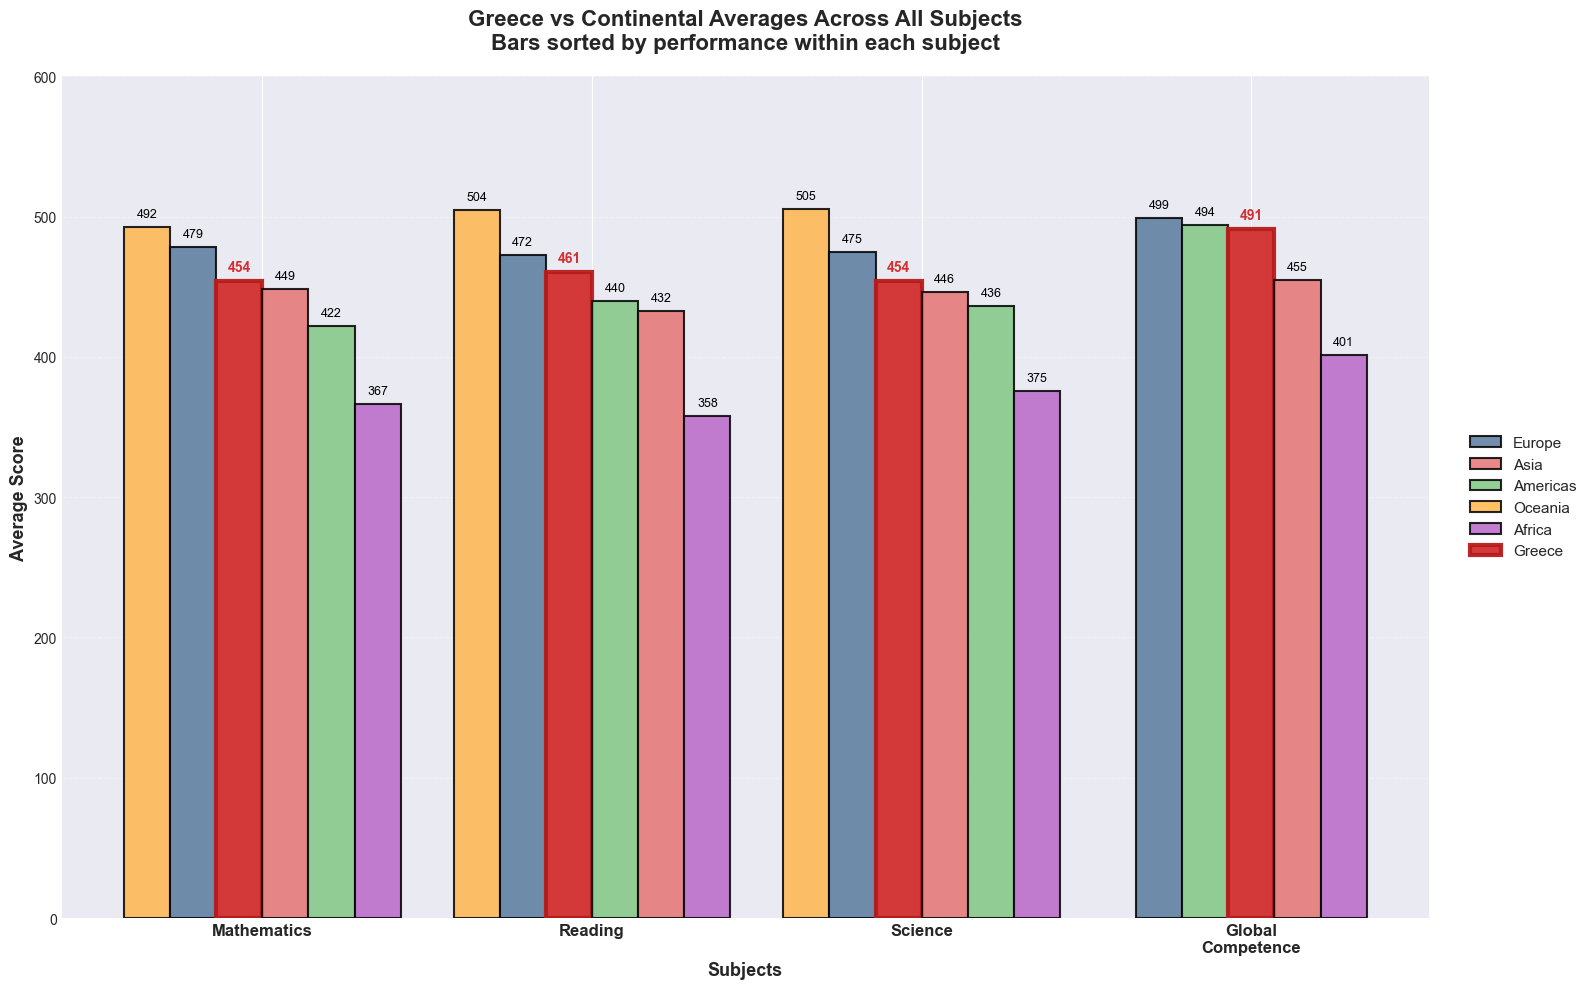

In [ ]:

# Define continent mappings

# Add continent column

# Calculate Greece scores
greece_scores = df[df['CNT'] == 'Greece'][SUBJECTS].mean()

# Calculate continental averages

continent_averages = {}
for continent in CONTINENTS:
    continent_df = df[df['Continent'] == continent]
    if len(continent_df) > 0:
        continent_averages[continent] = continent_df[SUBJECTS].mean()

# Create figure
fig, ax = plt.subplots(figsize=(16, 10))

# Bar width and positions
n_subjects = len(SUBJECTS)
bar_width = 0.14
x_base = np.arange(n_subjects)

# Track which groups are plotted for legend
plotted_groups = set()

# For each subject, sort the groups by score
for subj_idx, subject in enumerate(SUBJECTS):
    # Collect scores for this subject (excluding NaN)
    scores_dict = {}
    for continent in CONTINENTS:
        if continent in continent_averages:
            score = continent_averages[continent][subject]
            if not np.isnan(score):
                scores_dict[continent] = score
    
    # Add Greece if not NaN
    if not np.isnan(greece_scores[subject]):
        scores_dict['Greece'] = greece_scores[subject]
    
    # Sort by score (high to low)
    sorted_groups = sorted(scores_dict.items(), key=lambda x: x[1], reverse=True)
    n_groups = len(sorted_groups)
    
    # Plot bars for this subject in sorted order
    for bar_idx, (group, value) in enumerate(sorted_groups):
        x_pos = x_base[subj_idx] + (bar_idx - n_groups/2 + 0.5) * bar_width
        
        is_greece = (group == 'Greece')
        bar = ax.bar(x_pos, value, bar_width,
                    color=CONTINENT_COLORS[group], 
                    alpha=0.95 if is_greece else 0.85,
                    edgecolor='#B71C1C' if is_greece else 'black',
                    linewidth=3 if is_greece else 1.5)
        
        # Track plotted groups for legend
        plotted_groups.add(group)
        
        # Add value labels on top of bars
        fontsize = 10 if is_greece else 9
        fontweight = 'bold' if is_greece else 'normal'
        color = '#D32F2F' if is_greece else 'black'
        ax.text(x_pos, value + 5, f'{value:.0f}',
                ha='center', va='bottom', fontsize=fontsize, 
                fontweight=fontweight, color=color)

# Formatting
ax.set_xlabel('Subjects', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Score', fontsize=13, fontweight='bold')
ax.set_title('Greece vs Continental Averages Across All Subjects\nBars sorted by performance within each subject', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_base)
ax.set_xticklabels(SUBJECT_NAMES, fontsize=12, fontweight='bold')
ax.set_ylim(0, 600)

# Create custom legend with only plotted groups
legend_elements = []
legend_order = CONTINENTS + ['Greece']
for group in legend_order:
    if group in plotted_groups:
        label = 'Greece' if group == 'Greece' else group
        legend_elements.append(Patch(facecolor=CONTINENT_COLORS[group], 
                                     edgecolor='#B71C1C' if group == 'Greece' else 'black',
                                     linewidth=3 if group == 'Greece' else 1.5,
                                     label=label, alpha=0.95 if group == 'Greece' else 0.85))

ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=11, framealpha=0.95, edgecolor='gray')

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

### Plot Number 8

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/2793785946.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_avgs = df.groupby('CNT')[subject].mean().sort_values(ascending=False).reset_index()
/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/2793785946.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_avgs = df.groupby('CNT')[subject].mean().sort_values(ascending=False).reset_index()
/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/2793785946.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a fu

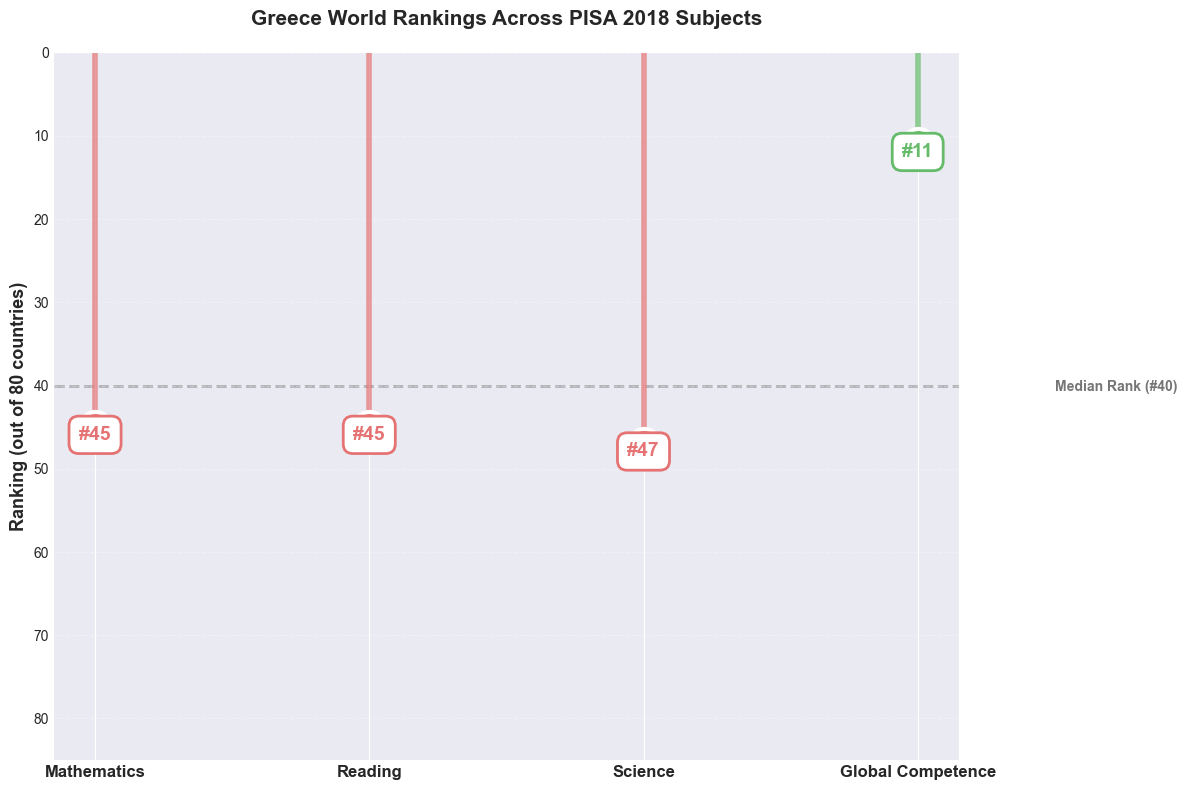

In [80]:

# Calculate rankings for Greece in each subject
rankings = {}

for subject in SUBJECTS:
    country_avgs = df.groupby('CNT')[subject].mean().sort_values(ascending=False).reset_index()
    greece_rank = country_avgs[country_avgs['CNT'] == 'Greece'].index[0] + 1
    total_countries = len(country_avgs)
    rankings[subject] = {'rank': greece_rank, 'total': total_countries}

# Prepare data
ranks = [rankings[s]['rank'] for s in SUBJECTS]
total = rankings['MATH']['total']

# Colors based on performance (lower rank = better = greener)
colors = ['#E57373', '#E57373', '#E57373', '#66BB6A']  # GLCM is green (good rank)

# Create plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot lollipops
for i, (subject, rank, color) in enumerate(zip(SUBJECT_NAMES, ranks, colors)):
    ax.plot([i, i], [0, rank], color=color, linewidth=4, alpha=0.7, zorder=1)
    ax.scatter(i, rank, s=500, color=color, edgecolors='white', linewidth=3, zorder=3)
    
    # Add rank label
    ax.text(i, rank + 2, f'#{rank}', ha='center', va='bottom', 
            fontsize=14, fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=color, linewidth=2))

# Add reference line for median rank
median_rank = total / 2
ax.axhline(median_rank, color='#757575', linestyle='--', linewidth=2, alpha=0.5, zorder=0)
ax.text(len(SUBJECTS) - 0.5, median_rank + 1, f'Median Rank (#{median_rank:.0f})', 
        fontsize=10, color='#757575', fontweight='bold', va='bottom')

# Formatting
ax.set_xticks(range(len(SUBJECT_NAMES)))
ax.set_xticklabels(SUBJECT_NAMES, fontsize=12, fontweight='bold')
ax.set_ylabel('Ranking (out of {} countries)'.format(total), fontsize=13, fontweight='bold')
ax.set_title('Greece World Rankings Across PISA 2018 Subjects', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylim(0, total + 5)
ax.invert_yaxis()  # Lower rank at top
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

### Plot Number 9

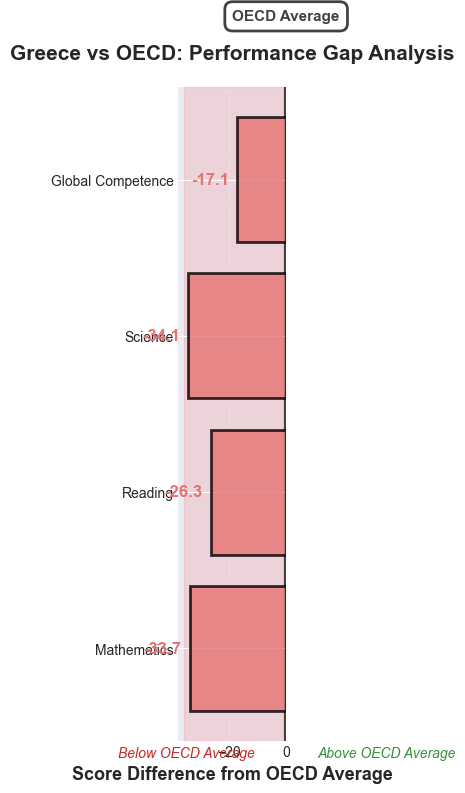

In [81]:

# Calculate OECD countries average
oecd_countries = ['Australia', 'Austria', 'Belgium', 'Canada', 'Chile', 'Colombia', 'Costa Rica',
                  'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
                  'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia',
                  'Lithuania', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway',
                  'Poland', 'Portugal', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland',
                  'Turkey', 'United Kingdom', 'United States']

df_oecd = df[df['CNT'].isin(oecd_countries)]

# Calculate OECD averages
oecd_avgs = df_oecd[SUBJECTS].mean()

# Calculate Greece averages
greece_avgs = df[df['CNT'] == 'Greece'][SUBJECTS].mean()

# Calculate differences (Greece - OECD)
differences = greece_avgs - oecd_avgs

# Prepare data
values = differences.values

# Colors: red for below OECD, green for above OECD
colors = ['#E57373' if v < 0 else '#66BB6A' for v in values]

# Create plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot bars
bars = ax.barh(SUBJECT_NAMES, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    x_pos = val + (3 if val > 0 else -3)
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, i, f'{val:+.1f}', va='center', ha=ha, 
            fontsize=12, fontweight='bold', color=colors[i])

# Add vertical line at zero
ax.axvline(0, color='#424242', linewidth=3, zorder=0)
ax.text(0, len(SUBJECT_NAMES), 'OECD Average', ha='center', va='bottom', 
        fontsize=11, fontweight='bold', color='#424242',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#424242', linewidth=2))

# Add shaded regions
ax.axvspan(ax.get_xlim()[0], 0, alpha=0.1, color='red', zorder=0)
ax.axvspan(0, ax.get_xlim()[1], alpha=0.1, color='green', zorder=0)
ax.text(-35, -0.7, 'Below OECD Average', fontsize=10, style='italic', color='#C62828', ha='center')
ax.text(35, -0.7, 'Above OECD Average', fontsize=10, style='italic', color='#388E3C', ha='center')

# Formatting
ax.set_xlabel('Score Difference from OECD Average', fontsize=13, fontweight='bold')
ax.set_title('Greece vs OECD: Performance Gap Analysis', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

### Plot Number 10

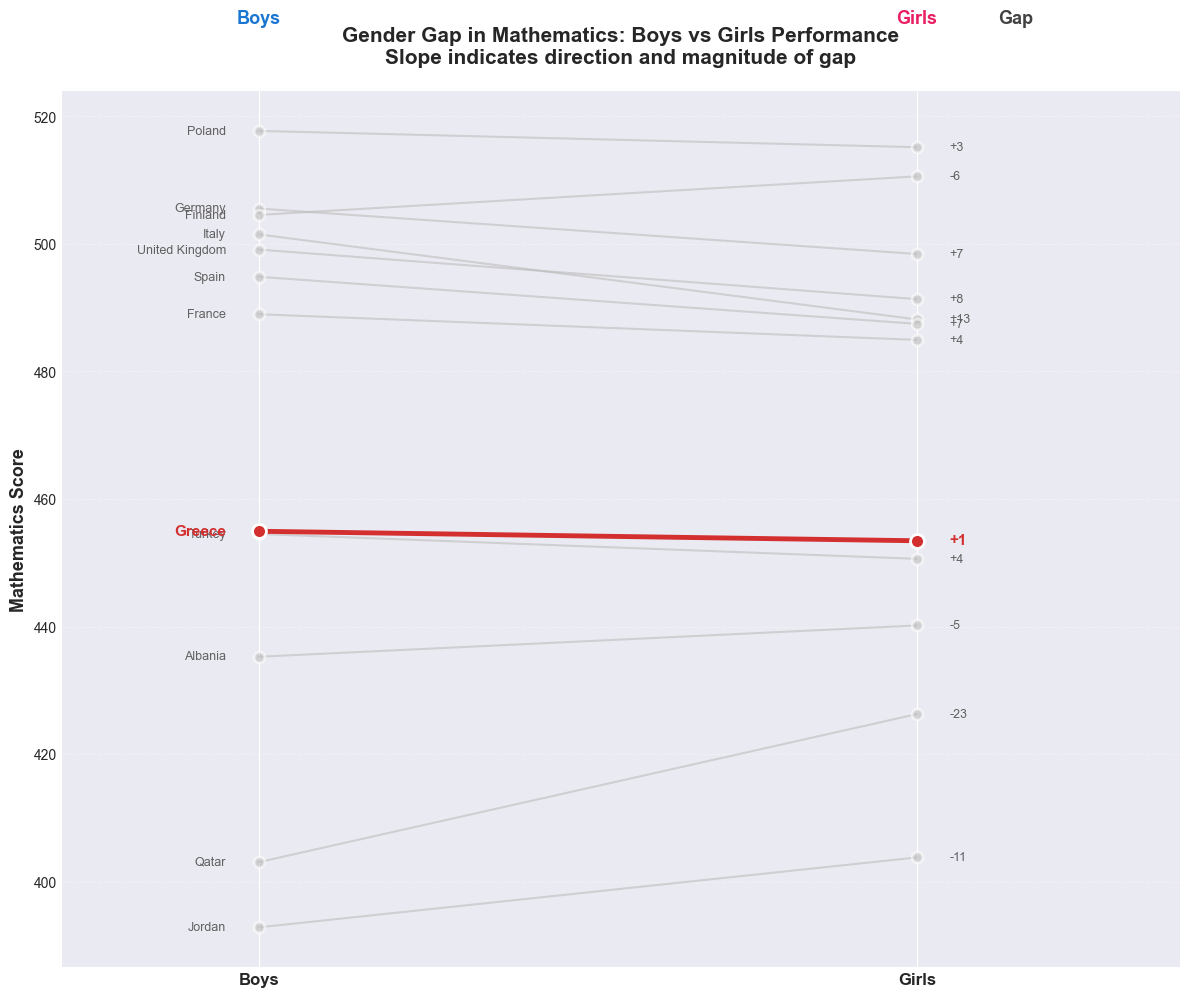

In [82]:

# Select countries for comparison
selected_countries = ['Finland', 'Greece', 'Turkey', 'Italy', 'Germany', 'France', 
                      'United Kingdom', 'Spain', 'Poland', 'Albania', 'Jordan', 'Qatar']

# Calculate gender averages for MATH
gender_data = []
for country in selected_countries:
    country_df = df[df['CNT'] == country]
    boys_avg = country_df[country_df['ST004D01T'] == 'Male']['MATH'].mean()
    girls_avg = country_df[country_df['ST004D01T'] == 'Female']['MATH'].mean()
    
    if not np.isnan(boys_avg) and not np.isnan(girls_avg):
        gender_data.append({
            'Country': country,
            'Boys': boys_avg,
            'Girls': girls_avg,
            'Gap': boys_avg - girls_avg
        })

gender_df = pd.DataFrame(gender_data).sort_values('Gap', ascending=False)

# Create plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot lines
for idx, row in gender_df.iterrows():
    if row['Country'] == 'Greece':
        color = '#D32F2F'
        linewidth = 3.5
        alpha = 1
        zorder = 10
    else:
        color = '#BDBDBD'
        linewidth = 1.5
        alpha = 0.6
        zorder = 1
    
    ax.plot([0, 1], [row['Boys'], row['Girls']], 
            color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)
    
    # Add dots
    ax.scatter([0, 1], [row['Boys'], row['Girls']], 
               s=100 if row['Country'] == 'Greece' else 60, 
               color=color, alpha=alpha, zorder=zorder+1, edgecolors='white', linewidth=2)

# Add country labels
for idx, row in gender_df.iterrows():
    # Left side (Boys)
    if row['Country'] == 'Greece':
        ax.text(-0.05, row['Boys'], row['Country'], ha='right', va='center', 
                fontsize=11, fontweight='bold', color='#D32F2F')
    else:
        ax.text(-0.05, row['Boys'], row['Country'], ha='right', va='center', 
                fontsize=9, color='#616161')
    
    # Right side (Girls) - only show gap
    gap_text = f"{row['Gap']:+.0f}"
    if row['Country'] == 'Greece':
        ax.text(1.05, row['Girls'], gap_text, ha='left', va='center', 
                fontsize=11, fontweight='bold', color='#D32F2F')
    else:
        ax.text(1.05, row['Girls'], gap_text, ha='left', va='center', 
                fontsize=9, color='#616161')

# Add column headers
ax.text(0, ax.get_ylim()[1] + 10, 'Boys', ha='center', va='bottom', 
        fontsize=13, fontweight='bold', color='#1976D2')
ax.text(1, ax.get_ylim()[1] + 10, 'Girls', ha='center', va='bottom', 
        fontsize=13, fontweight='bold', color='#E91E63')
ax.text(1.15, ax.get_ylim()[1] + 10, 'Gap', ha='center', va='bottom', 
        fontsize=13, fontweight='bold', color='#424242')

# Formatting
ax.set_xlim(-0.3, 1.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Boys', 'Girls'], fontsize=12, fontweight='bold')
ax.set_ylabel('Mathematics Score', fontsize=13, fontweight='bold')
ax.set_title('Gender Gap in Mathematics: Boys vs Girls Performance\nSlope indicates direction and magnitude of gap', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

### Plot Number 11

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_30513/390029318.py:92: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/data_visualisation/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


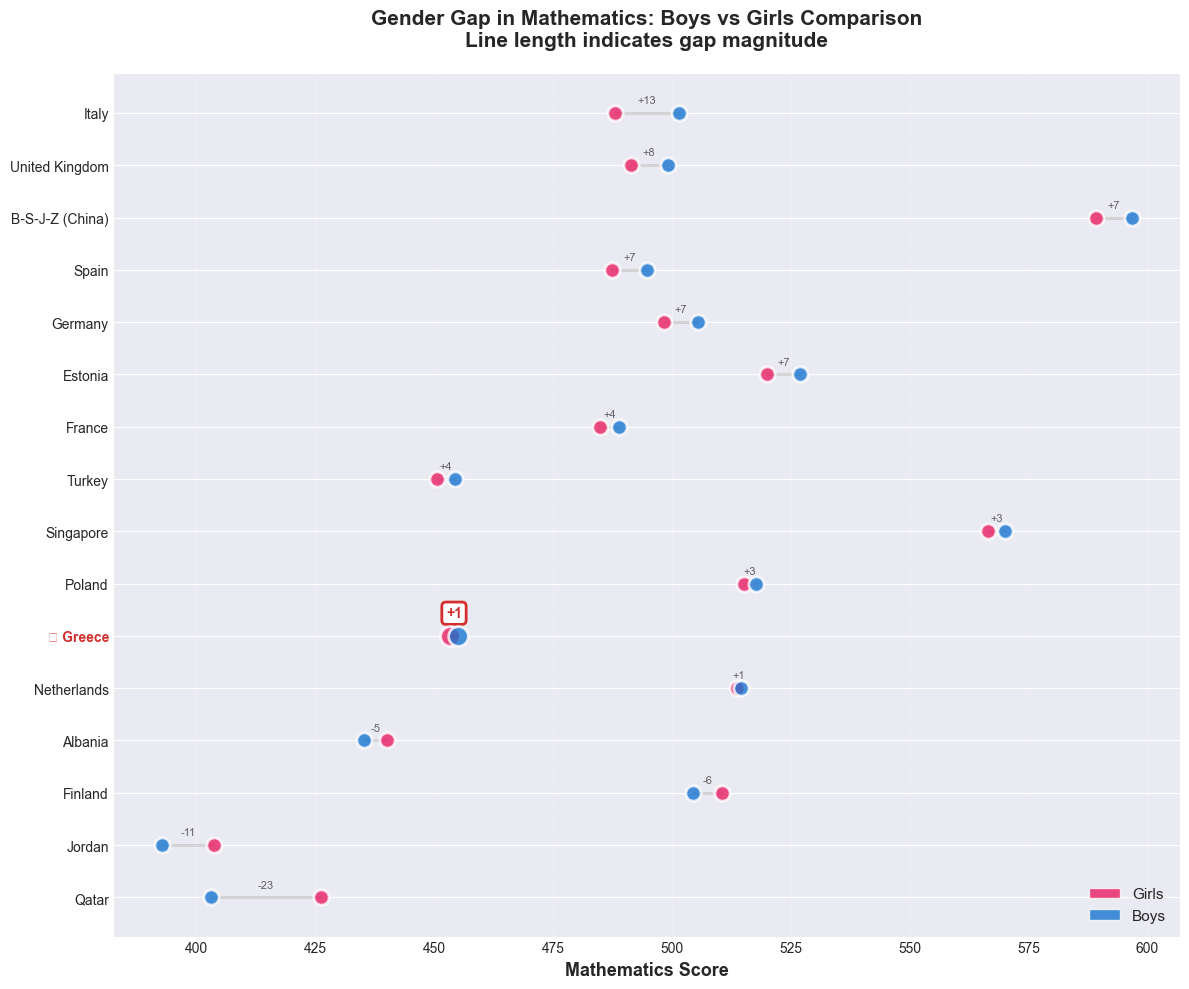

In [83]:

# Select countries for comparison
selected_countries = ['Finland', 'Greece', 'Turkey', 'Italy', 'Germany', 'France', 
                      'United Kingdom', 'Spain', 'Poland', 'Albania', 'Jordan', 'Qatar',
                      'B-S-J-Z (China)', 'Singapore', 'Netherlands', 'Estonia']

# Calculate gender averages for MATH
gender_data = []
for country in selected_countries:
    country_df = df[df['CNT'] == country]
    boys_avg = country_df[country_df['ST004D01T'] == 'Male']['MATH'].mean()
    girls_avg = country_df[country_df['ST004D01T'] == 'Female']['MATH'].mean()
    
    if not np.isnan(boys_avg) and not np.isnan(girls_avg):
        gender_data.append({
            'Country': country,
            'Boys': boys_avg,
            'Girls': girls_avg,
            'Gap': boys_avg - girls_avg
        })

gender_df = pd.DataFrame(gender_data).sort_values('Gap', ascending=True)

# Create plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot dumbbells
for idx, row in gender_df.iterrows():
    y_pos = gender_df.index.get_loc(idx)
    
    if row['Country'] == 'Greece':
        line_color = '#D32F2F'
        linewidth = 3
        alpha = 1
        zorder = 10
    else:
        line_color = '#BDBDBD'
        linewidth = 2
        alpha = 0.6
        zorder = 1
    
    # Draw line connecting boys and girls
    ax.plot([row['Girls'], row['Boys']], [y_pos, y_pos], 
            color=line_color, linewidth=linewidth, alpha=alpha, zorder=zorder)
    
    # Girls dot (left)
    ax.scatter(row['Girls'], y_pos, s=200 if row['Country'] == 'Greece' else 120, 
               color='#E91E63', alpha=0.8, zorder=zorder+1, edgecolors='white', linewidth=2)
    
    # Boys dot (right)
    ax.scatter(row['Boys'], y_pos, s=200 if row['Country'] == 'Greece' else 120, 
               color='#1976D2', alpha=0.8, zorder=zorder+1, edgecolors='white', linewidth=2)
    
    # Add gap value
    mid_point = (row['Boys'] + row['Girls']) / 2
    gap_text = f"{row['Gap']:+.0f}"
    if row['Country'] == 'Greece':
        ax.text(mid_point, y_pos + 0.3, gap_text, ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#D32F2F',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#D32F2F', linewidth=2))
    else:
        ax.text(mid_point, y_pos + 0.15, gap_text, ha='center', va='bottom', 
                fontsize=8, color='#616161')

# Country labels
country_labels = ['★ ' + c if c == 'Greece' else c for c in gender_df['Country']]
ax.set_yticks(range(len(gender_df)))
ax.set_yticklabels(country_labels, fontsize=10)

# Highlight Greece label
ytick_labels = ax.get_yticklabels()
for label in ytick_labels:
    if 'Greece' in label.get_text():
        label.set_color('#D32F2F')
        label.set_fontweight('bold')

# Add legend
legend_elements = [
    Patch(facecolor='#E91E63', edgecolor='white', label='Girls', alpha=0.8),
    Patch(facecolor='#1976D2', edgecolor='white', label='Boys', alpha=0.8)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.95)

# Formatting
ax.set_xlabel('Mathematics Score', fontsize=13, fontweight='bold')
ax.set_title('Gender Gap in Mathematics: Boys vs Girls Comparison\nLine length indicates gap magnitude', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Plot Number 12

## TODO: Use Py Shiny for interactive plots?